# Import libraries

In [1]:
# General libraries
import gc
import json
from scripts.model import FF
import numpy as np
%pip install -q --upgrade git+https://github.com/Dralliag/opera-python.git
from opera import Mixture
from torch_geometric import seed_everything
from torch_geometric.nn.conv import *

# GraphToolbox
from graphtoolbox.data.dataset import *
from graphtoolbox.interpretability.explain import *
from graphtoolbox.models.gnn import *
from graphtoolbox.optim.optimizer import *
from graphtoolbox.training.metrics import *
from graphtoolbox.training.trainer import Trainer
from graphtoolbox.utils.attention import *
from graphtoolbox.utils.helper_functions import *
from graphtoolbox.utils.visualizations import *

# Autoreload
%load_ext autoreload
%autoreload 2


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Import data

In [2]:
### GLOBAL VARIABLES
DATASET = 'rfrance' # 'rfrance', 'weave'
OPTIMIZE = False
TRAIN = True # whether to train GNNs/FF or just evaluate
OUT_CHANNELS = 48

# Device priority: mps (Apple Silicon) -> cuda -> cpu
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Selected DEVICE: {DEVICE}")

Selected DEVICE: mps


In [3]:
if DATASET == 'weave':
    print("Weave Dataset")
    data_kwargs = {
        'node_var': 'id_unique',
        'dummies': ['instant', 'id_uniqueInt',],
        'day_inf_train': '2024-02-13',
        'day_sup_train': '2024-02-23',
        'day_inf_val': '2024-02-23',
        'day_sup_val': '2024-02-25',
        'day_inf_test': '2024-02-25',
        'day_sup_test': '2024-02-29'
    }

    dataset_kwargs = {
        'adj_matrix': 'dtw',
        'features_base': ['instant', 'id_uniqueInt', 'weekday'] + [f'consumption_l{t}' for t in range(1, 48+1)],
        'target_base': 'consumption',
    }

    nrows, ncols = 4, 7

    data = DataClass(path_train='./data/weave/train_weave.csv', 
                    path_test='./data/weave/test_weave.csv', 
                    data_kwargs=data_kwargs,
                    folder_config='.')

    graph_dataset_train = GraphDataset(data=data, period='train', 
                                    graph_folder='./graph_representations_weave',
                                    dataset_kwargs=dataset_kwargs,
                                    out_channels=OUT_CHANNELS)
    graph_dataset_val = GraphDataset(data=data, period='val', 
                                    scalers_feat=graph_dataset_train.scalers_feat, 
                                    scalers_target=graph_dataset_train.scalers_target,
                                    graph_folder='./graph_representations_weave',
                                    dataset_kwargs=dataset_kwargs,
                                    out_channels=OUT_CHANNELS)
    graph_dataset_test = GraphDataset(data=data, period='test',
                                    scalers_feat=graph_dataset_train.scalers_feat, 
                                    scalers_target=graph_dataset_train.scalers_target,
                                    graph_folder='./graph_representations_weave',
                                    dataset_kwargs=dataset_kwargs,
                                    out_channels=OUT_CHANNELS)
else:    
    print("Regional French Dataset")
    data_kwargs = {
        'node_var': 'Region',
        'dummies': ['Instant', 'JourSemaine', 'DayType', 'offset'],
        'day_inf_train': '2015-01-01',
        'day_sup_train': '2018-01-01',
        'day_inf_val': '2018-01-01',
        'day_sup_val': '2018-12-31',
        'day_inf_test': '2019-01-01',
        'day_sup_test': '2019-12-31'
    }

    dataset_kwargs = {
        'adj_matrix': 'gl3sr',
        'features_base': ['temp', 'nebu', 'wind', 'tempMax', 'tempMin', 'Posan', 'Instant', 'JourSemaine', 'JourFerie', 'offset', 'DayType', 'Weekend', 'temp_liss_fort', 'temp_liss_faible'] + [f'load_l{t}' for t in range(1, 48+1)],
        'feature_groups': {
            'temp':     ['temp', 'tempMax', 'tempMin', 'temp_liss_fort'],
            'calendar': ['Instant', 'JourSemaine', 'JourFerie'],
            'lags':     [f'load_l{t}' for t in range(1, 49)],
            'weather':  ['nebu', 'wind']
        },
        'target_base': 'load',
    }

    nrows, ncols = 3, 4

    data = DataClass(path_train='./data/rfrance/train2.csv', 
                    path_test='./data/rfrance/test2.csv', 
                    data_kwargs=data_kwargs,
                    folder_config='.')

    graph_dataset_train = GraphDataset(data=data, period='train', 
                                      graph_folder='./graph_representations_rfrance',
                                      dataset_kwargs=dataset_kwargs,
                                      out_channels=OUT_CHANNELS)
    graph_dataset_val = GraphDataset(data=data, period='val', 
                                     scalers_feat=graph_dataset_train.scalers_feat, 
                                     scalers_target=graph_dataset_train.scalers_target,
                                     graph_folder='./graph_representations_rfrance',
                                     dataset_kwargs=dataset_kwargs,
                                     out_channels=OUT_CHANNELS)
    graph_dataset_test = GraphDataset(data=data, period='test',
                                      scalers_feat=graph_dataset_train.scalers_feat, 
                                      scalers_target=graph_dataset_train.scalers_target,
                                      graph_folder='./graph_representations_rfrance',
                                      dataset_kwargs=dataset_kwargs,
                                      out_channels=OUT_CHANNELS)

Regional French Dataset


# GNN Optimization

In [4]:
import torch
import inspect
from torch_geometric.nn import conv as pyg_conv

print("Auto-testing all torch_geometric.nn.conv layers\n")

num_nodes = 15
x = torch.randn(num_nodes, 16)
edge_index = torch.randint(0, num_nodes, (2, 40))

success, fail, skipped = [], [], []

skip_keywords = [
    "CuGraph",  
    "Hetero", "HAN", "HGT", "HEAT",  
    "Point", "PPF", "Hypergraph", 
]

for name, cls in inspect.getmembers(pyg_conv, inspect.isclass):
    if not name.endswith("Conv"):
        continue
    if any(k in name for k in skip_keywords):
        print(f"⏩ {name:<25} -> skipped (unsupported on macOS)")
        skipped.append(name)
        continue

    try:
        model = myGNN(
            in_channels=16,
            hidden_channels=32,
            out_channels=1,
            num_layers=2,
            conv_class=cls,
        )
        with torch.no_grad():
            out = model(x, edge_index)

        if not torch.is_tensor(out):
            raise TypeError("Output is not a tensor")
        success.append((name, tuple(out.shape)))
        print(f"✅ {name:<25} -> output {tuple(out.shape)}")

    except Exception as e:
        msg = str(e).splitlines()[0] if str(e) else "<no message>"
        if "pylibcugraphops" in msg:
            print(f"⏩ {name:<25} -> skipped (requires RAPIDS CUDA libs)")
            skipped.append(name)
            continue
        fail.append((name, type(e).__name__, msg))
        print(f"❌ {name:<25} -> {type(e).__name__}: {msg}")

print(f"\n✅ Successful: {len(success)}")
print(f"❌ Failed:     {len(fail)}")
print(f"⏩ Skipped:    {len(skipped)}")

if fail:
    print("\nExamples of failures:")
    for n, err, msg in fail[:10]:
        print(f"  - {n}: {err} ({msg})")


Auto-testing all torch_geometric.nn.conv layers

✅ AGNNConv                  -> output (15, 1)
✅ ARMAConv                  -> output (15, 1)
✅ AntiSymmetricConv         -> output (15, 1)
✅ CGConv                    -> output (15, 1)
✅ ChebConv                  -> output (15, 1)
✅ ClusterGCNConv            -> output (15, 1)
⏩ CuGraphGATConv            -> skipped (unsupported on macOS)
⏩ CuGraphRGCNConv           -> skipped (unsupported on macOS)
⏩ CuGraphSAGEConv           -> skipped (unsupported on macOS)
✅ DNAConv                   -> output (15, 1)
❌ DirGNNConv                -> AttributeError: type object 'GCNConv' has no attribute 'in_channels'
❌ DynamicEdgeConv           -> TypeError: DynamicEdgeConv.__init__() missing 2 required positional arguments: 'nn' and 'k'
✅ ECConv                    -> output (15, 1)
✅ EGConv                    -> output (15, 1)
✅ EdgeConv                  -> output (15, 1)
✅ FAConv                    -> output (15, 1)
❌ FastRGCNConv              -> TypeE

In [5]:
seed=42
seed_everything(seed)
if OPTIMIZE:
    gnn_opt = Optimizer(model=AdditiveGraphModel, 
                        dataset_train=graph_dataset_train, 
                        dataset_val=graph_dataset_val, 
                        out_channels=OUT_CHANNELS,
                        conv_class=GCNConv,
                        optim_kwargs={'num_layers': (1, 5),
                                      'hidden_channels': (32, 512),
                                      'lr': (1e-5, 1e-1),
                                    },
                        num_epochs=200)
    gnn_opt.optimize(n_trials=150)

# GNN Training

In [6]:
SELECTED_MODELS = ['GCNConv']
ADDITIVE = False
# Load configs where each top-level key is the conv name
if ADDITIVE:
    config_path = f'configs/config_{DATASET}_add.json'
else:
    config_path = f'configs/config_{DATASET}.json'
if not os.path.isfile(config_path):
    raise FileNotFoundError(f"Config file not found: {config_path}")

_CONV_MAP = {
    'GCNConv': GCNConv,
    'GCN2Conv': GCN2Conv,
    'GATConv': GATConv,
    'GATv2Conv': GATv2Conv,
    'TransformerConv': TransformerConv,
    'TAGConv': TAGConv,
    'ChebConv': ChebConv,
    'APPNP': APPNP,
    'GraphSAGE': SAGEConv,
    'ARMAConv': ARMAConv,
    'ResGatedGraphConv': ResGatedGraphConv,
    'FiLMConv': FiLMConv,
    'AGNNConv': AGNNConv,
}

with open(config_path, 'r') as f:
    raw = json.load(f)

# Build CONFIGS from the new JSON shape
_selection = globals().get('SELECTED_MODELS', None)
if isinstance(_selection, str):
    _selection = [s.strip() for s in _selection.split(',') if s.strip()]

available_models = list(raw.keys())
to_keep = available_models if not _selection else [m for m in _selection if m in raw]

if _selection:
    unknown = [m for m in _selection if m not in raw]
    if unknown:
        print(f"Warning: unknown model(s) ignored: {unknown}. Available: {available_models}")

CONFIGS = {}
for model_name in to_keep:
    conf = raw[model_name]
    conv_key = conf.get('conv', model_name)  # utilise la clé si 'conv' absent

    if isinstance(conv_key, str):
        if conv_key not in _CONV_MAP:
            raise KeyError(f"Unknown conv '{conv_key}' for model '{model_name}'. "
                           f"Available convs: {list(_CONV_MAP.keys())}")
        conv_cls = _CONV_MAP[conv_key]
    else:
        conv_cls = conv_key

    CONFIGS[model_name] = {
        'adj_matrix': conf['adj_matrix'],
        'conv': conv_cls,
        'params': conf['params'],
    }

print(f"Loaded CONFIGS from {config_path}: {list(CONFIGS.keys())}")

results = []
preds = {}
N = 1  # Number of runs per model
os.makedirs(f"results_{DATASET}", exist_ok=True)

if TRAIN:
    for model_name, cfg in CONFIGS.items():
        conv_class = cfg["conv"]
        adj_matrix = cfg["adj_matrix"]
        graph_dataset_train._set_adj_matrix(adj_matrix=adj_matrix)
        graph_dataset_val._set_adj_matrix(adj_matrix=adj_matrix)
        graph_dataset_test._set_adj_matrix(adj_matrix=adj_matrix)

        params = cfg["params"]
        results_rmse, results_mape = [], []

        for i in range(N):
            print(f"\n--- {model_name} | Run {i+1}/{N} ---")
            gc.collect()
            torch.cuda.empty_cache()

            conv_kwargs = {}
            for k in ["heads", "K", "alpha"]:
                if k in params:
                    conv_kwargs[k] = params[k]

            if ADDITIVE:
                model = AdditiveGraphModel(
                    feature_group_dims=graph_dataset_train.feature_group_dims,
                    hidden_channels=params.get("hidden_channels", 64),
                    num_layers=params.get("gnn_layers", params.get("num_layers", 2)),
                    out_channels=OUT_CHANNELS,
                    conv_class=conv_class,
                    conv_kwargs=conv_kwargs,
                ).to(DEVICE)
            else:
                if conv_class is not SAGEConv:
                    model = myGNN(
                        in_channels=graph_dataset_train.num_node_features,
                        num_layers=params["num_layers"],
                        hidden_channels=params["hidden_channels"],
                        out_channels=OUT_CHANNELS,
                        conv_class=conv_class,
                        conv_kwargs=conv_kwargs
                    ).to(DEVICE)
                else:
                    model = myGNN(
                        in_channels=graph_dataset_train.num_node_features,
                        num_layers=params["num_layers"],
                        hidden_channels=params["hidden_channels"],
                        out_channels=OUT_CHANNELS,
                        conv_class=SAGEConv,
                        conv_kwargs=conv_kwargs | {'project': 'True'}
                    ).to(DEVICE)
            
            trainer = Trainer(
                model=model,
                dataset_train=graph_dataset_train,
                dataset_val=graph_dataset_val,
                dataset_test=graph_dataset_test,
                batch_size=params['batch_size'],
                return_attention=False,
                model_kwargs={'lr': params['lr'], 'num_epochs': 300},
                lam_reg=0
            )

            if ADDITIVE:
                pred_model_test, target_test, edge_index, edge_weight, group_outputs = trainer.train(
                    plot_loss=False,
                    force_training=False,
                    save=False,
                    patience=300,
                )
            else:
                pred_model_test, target_test, edge_index, edge_weight = trainer.train(
                    plot_loss=False,
                    force_training=False,
                    save=False,
                    patience=300,
                )

            preds[f"{model_name}_run{i}"] = {
                "predictions": pred_model_test,
            }

            rmse = RMSE(preds=pred_model_test.sum(dim=0).cpu().detach(), targets=target_test.sum(dim=0).cpu().detach()).item()
            results_rmse.append(rmse)
            mape = MAPE(preds=pred_model_test.sum(dim=0).cpu().detach(), targets=target_test.sum(dim=0).cpu().detach()).item()
            results_mape.append(mape)

        results.append({
            "model": model_name,
            "min_rmse": np.min(results_rmse),
            "mean_rmse": np.mean(results_rmse),
            "max_rmse": np.max(results_rmse),
            "std_rmse": np.std(results_rmse),
            "min_mape": np.min(results_mape),
            "mean_mape": np.mean(results_mape),
            "max_mape": np.max(results_mape),
            "std_mape": np.std(results_mape)
        })  
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='mean_rmse')
    # average predictions over runs for each model
    for model_name in CONFIGS.keys():
        all_runs = [preds[f"{model_name}_run{i}"]["predictions"] for i in range(N)]
        avg_pred = torch.mean(torch.stack(all_runs), dim=0)
        preds[f"{model_name}_avg"] = {
            "predictions": avg_pred,
        }

    # compute metrics for averaged predictions
    for model_name in CONFIGS.keys():
        avg_pred = preds[f"{model_name}_avg"]["predictions"]
        rmse = RMSE(preds=avg_pred.sum(dim=0).cpu().detach(), targets=target_test.sum(dim=0).cpu().detach()).item()
        mape = 100*MAPE(preds=avg_pred.sum(dim=0).cpu().detach(), targets=target_test.sum(dim=0).cpu().detach()).item()
        print(f"{model_name} | Averaged Predictions | RMSE: {rmse:.4f}, MAPE: {mape:.4f}")

    # average predictions over all models
    all_model_preds = [preds[f"{model_name}_avg"]["predictions"] for model_name in CONFIGS.keys()]
    final_avg_pred = torch.mean(torch.stack(all_model_preds), dim=0)
    final_rmse = RMSE(preds=final_avg_pred.sum(dim=0).cpu().detach(), targets=target_test.sum(dim=0).cpu().detach()).item()
    final_mape = 100*MAPE(preds=final_avg_pred.sum(dim=0).cpu().detach(), targets=target_test.sum(dim=0).cpu().detach()).item()
    print(f"All Models Averaged Predictions | RMSE: {final_rmse:.4f}, MAPE: {final_mape:.4f}")


Loaded CONFIGS from configs/config_weave.json: ['GCNConv']

--- GCNConv | Run 1/1 ---
Loading pretrained model.
GCNConv | Averaged Predictions | RMSE: 13880.5068, MAPE: 7.4349
All Models Averaged Predictions | RMSE: 13880.5068, MAPE: 7.4349


In [7]:
# save both preds in results_rfrance/ARMAConv/ARMAConv_{i}.pt
for model_name in CONFIGS.keys():
    model_folder = f"results_{DATASET}/{model_name}"
    os.makedirs(model_folder, exist_ok=True)
    for key in preds.keys():
        if key.startswith(model_name):
            save_path = os.path.join(model_folder, f"{key}.pt")
            torch.save(preds[key], save_path)
            print(f"Saved predictions for {key} at {save_path}")

Saved predictions for GCNConv_run0 at results_weave/GCNConv/GCNConv_run0.pt
Saved predictions for GCNConv_avg at results_weave/GCNConv/GCNConv_avg.pt


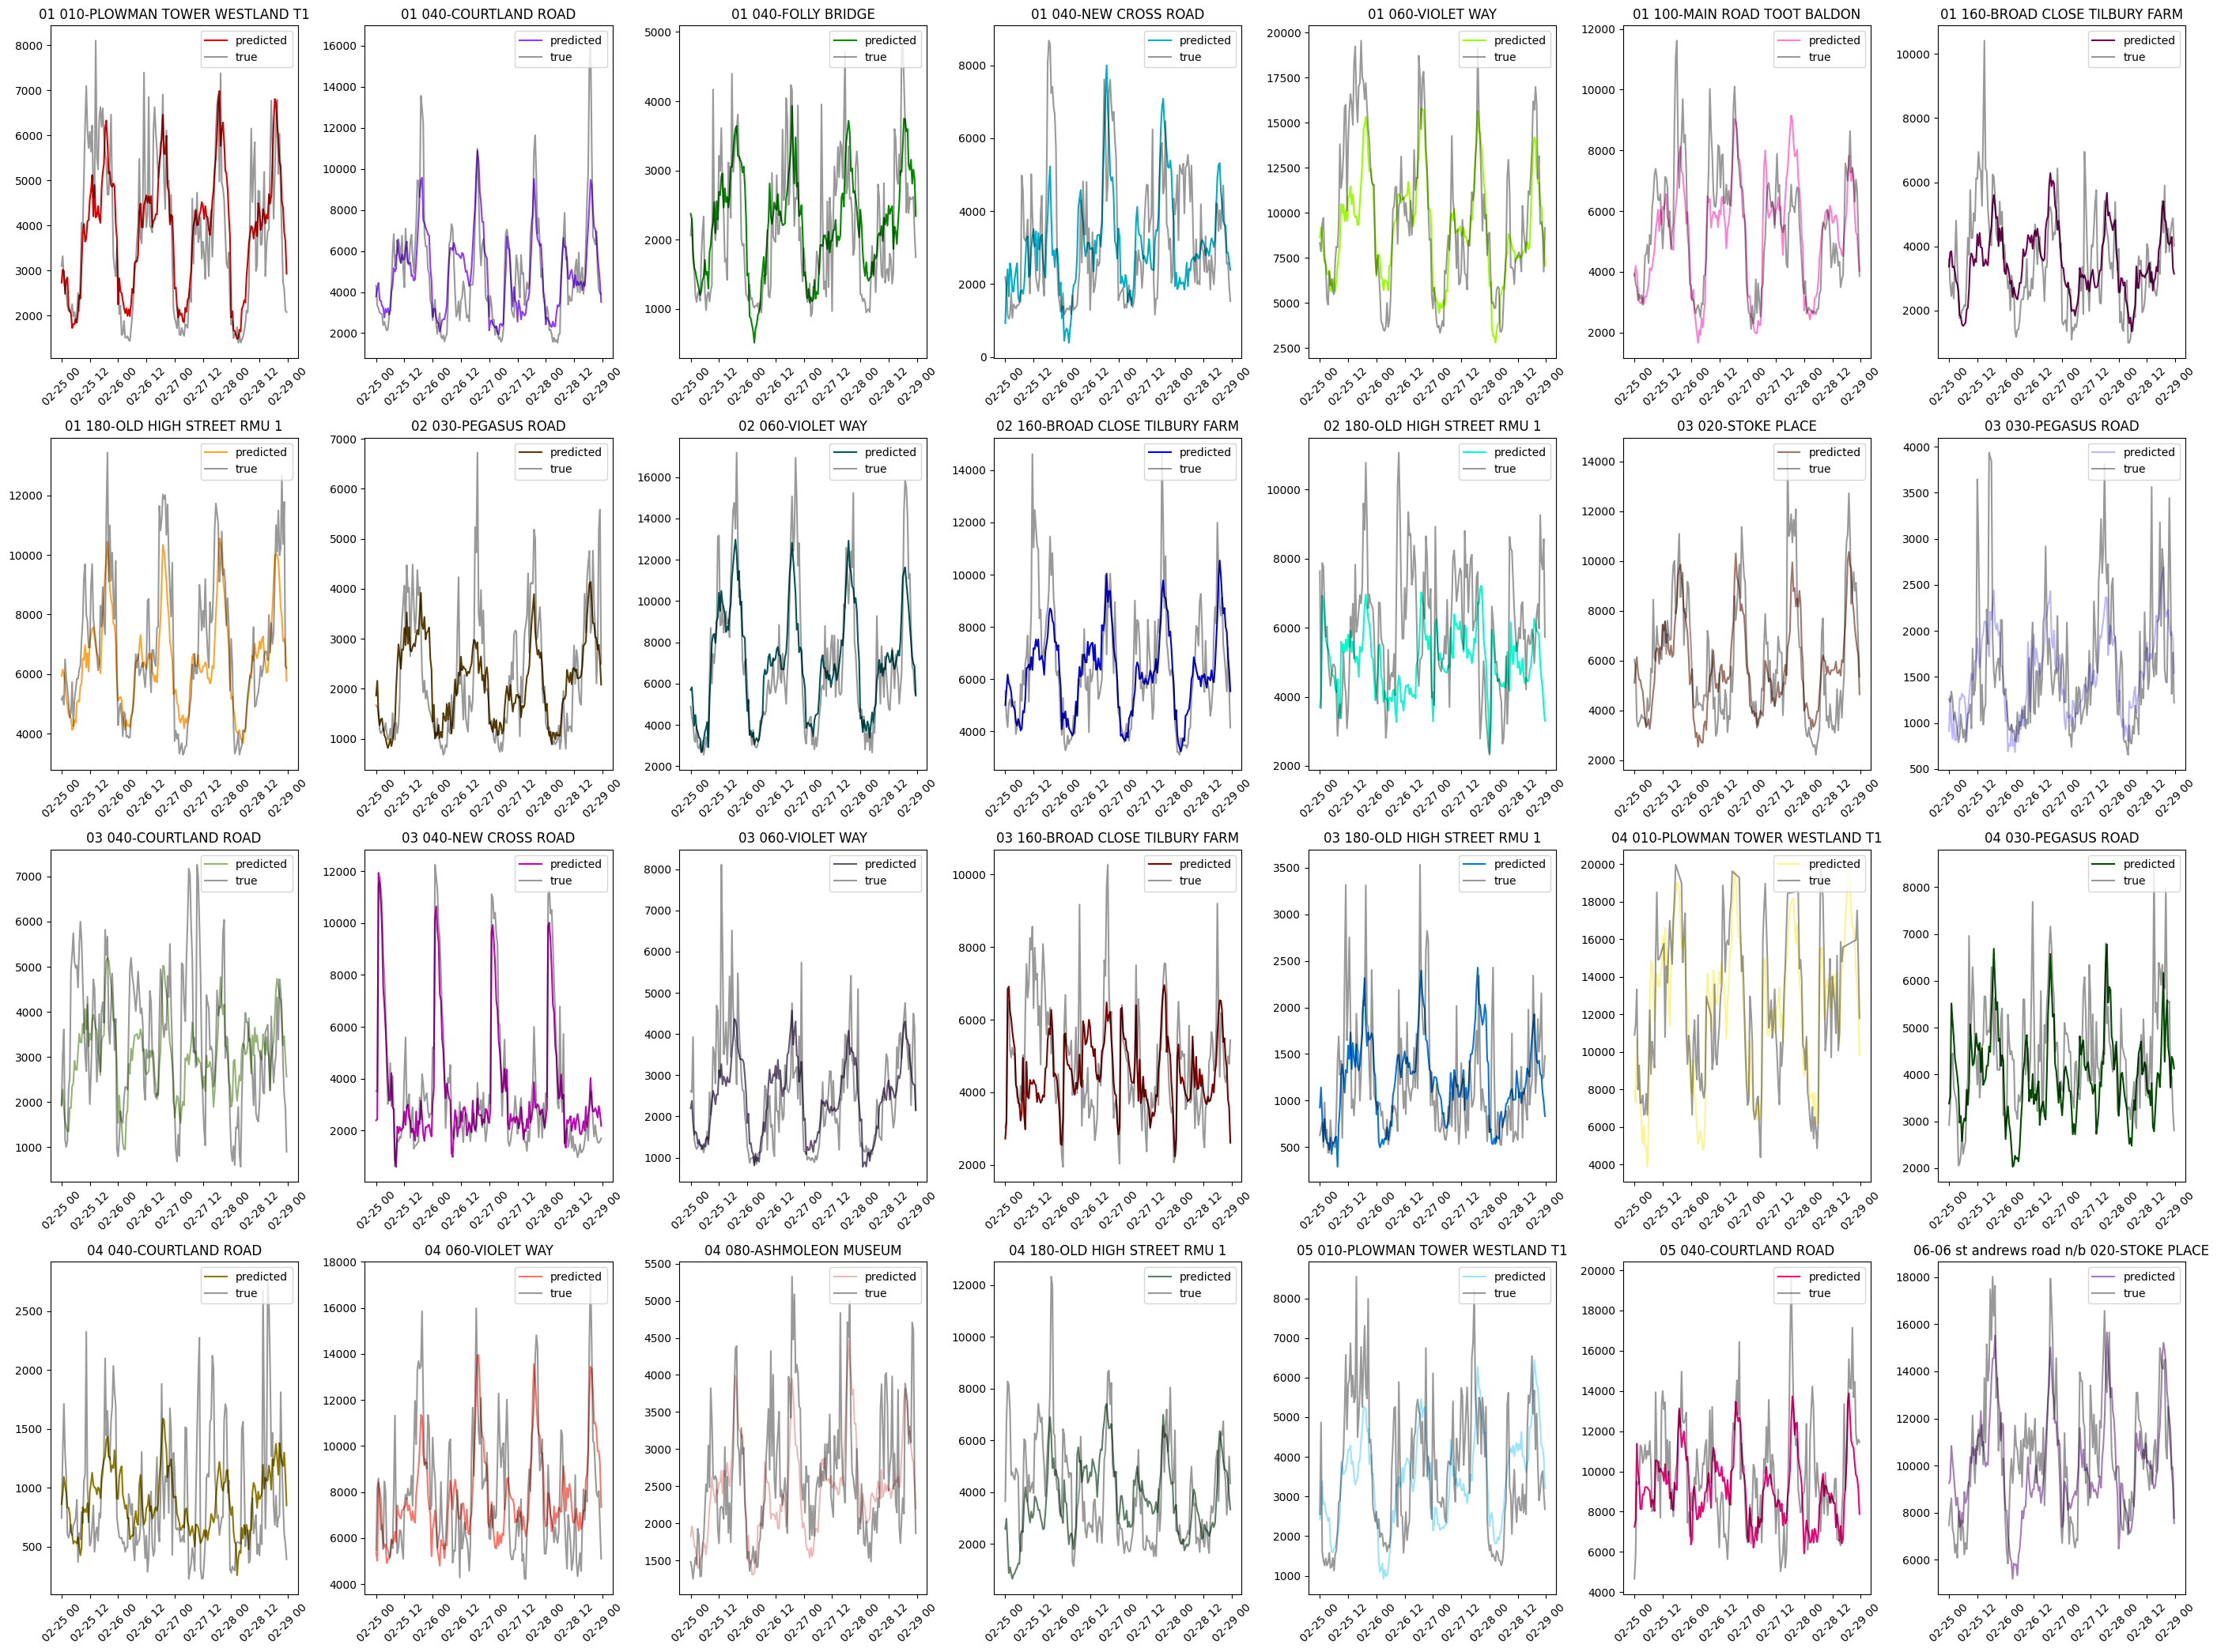

In [8]:
if TRAIN:
    plot_nodes(true=target_test, pred=pred_model_test, graph_dataset=graph_dataset_test, nrows=nrows, ncols=ncols)

In [9]:
if ADDITIVE:
    group_name = 'temp'
    contrib = group_outputs[group_name]  # Tensor [num_nodes, T_pred]
    feat_mats = get_group_feature_mats(group_name, data, graph_dataset_train, graph_dataset_test)

    for idx, (feat, X) in enumerate(feat_mats.items()):
        # Use full overlap, grouped by 48 instants (truncate to multiple of 48)
        Tm = min(X.shape[1], contrib.shape[1])
        if Tm < 48:
            continue
        x_mid, ale_mean, ale_std = compute_ALE_avg_over_instants(
            torch.as_tensor(X[:, :Tm]),  # or X[:, -Tm:] if you prefer aligning to the end
            contrib[:, :Tm],
            n_bins=20, period=48, align='start'  # set align='end' to align from the right@
        )
        plot_ALE_avg(x_mid, ale_mean, ale_std, label=f"load:{feat}", color=f"C{idx % 10}")

    for feat, X in feat_mats.items():
        Tm = min(X.shape[1], contrib.shape[1])
        if Tm < 48:
            continue
        x_mid, ale_nodes, counts = compute_ALE_per_node_avg_over_instants(
            torch.as_tensor(X[:, :Tm]),  # or X[:, -Tm:] with align='end'
            contrib[:, :Tm],
            n_bins=20, period=48, align='start'
        )
        plot_ALE_nodes(x_mid, ale_nodes, counts=counts, title_prefix=f"load:{feat} (avg over 48 instants)")


In [10]:
if ADDITIVE: 
    # ---- Build and plot importance (averaged over 48 instants, aggregated across nodes) ----
    df_imp = compute_feature_importances_from_ALE(
        group_outputs, data, graph_dataset_train, graph_dataset_test,
        n_bins=20, mode='avg48', period=48, align='start', method='rms'
    )
    topk_view = plot_feature_importance_bar(df_imp, top_k=10, normalize='sum', color='C0')

    # ---- Alternative: per-node ALE averaged over 48 instants, then aggregated across nodes ----
    df_imp_regional = compute_feature_importances_from_ALE(
        group_outputs, data, graph_dataset_train, graph_dataset_test,
        n_bins=20, mode='per_node_avg48', period=48, align='start', method='rms'
    )
    topk_view_reg = plot_feature_importance_bar(df_imp_regional, top_k=10, normalize='sum', color='C1')

In [11]:
if ADDITIVE:

    import shap
    import torch
    import numpy as np
    from torch_geometric.loader import DataLoader  # use PyG DataLoader for Data objects

    def _shap_to_2d(shap_raw, output_agg='sum'):
        """
        Convert various SHAP return types to 2D array [B, D].
        - shap_raw can be: np.ndarray, list of arrays (per-output), or shap.Explanation
        - If 3D [B, D, O], aggregate outputs via 'sum' or 'first'
        """
        # shap.Explanation
        if hasattr(shap_raw, 'values'):
            arr = np.asarray(shap_raw.values)
        else:
            arr = shap_raw

        # list of outputs -> stack and aggregate
        if isinstance(arr, list):
            mats = [np.asarray(a) for a in arr]  # each [B,D] or [B,D,1]
            if any(m.ndim == 3 for m in mats):
                mats = [m.squeeze(-1) if m.ndim == 3 and m.shape[-1] == 1 else m for m in mats]
            if output_agg == 'sum':
                arr2d = np.sum(np.stack(mats, axis=0), axis=0)
            else:
                arr2d = mats[0]
            return np.asarray(arr2d)

        # ndarray
        arr = np.asarray(arr)
        if arr.ndim == 3:
            # [B, D, O] -> aggregate outputs
            if output_agg == 'sum':
                arr = np.nansum(arr, axis=-1)
            else:
                arr = arr[..., 0]
        elif arr.ndim == 1:
            arr = arr[:, None]
        elif arr.ndim != 2:
            # Unknown shape -> try to flatten features dimension
            arr = arr.reshape(arr.shape[0], -1)
        return arr

    def _prepare_shap_inputs(
        X_bg_flat: np.ndarray,
        X_eval_flat: np.ndarray,
        q_clip: float = 0.001,
        min_std: float = 1e-8,
        jitter: float = 1e-6
    ):
        """
        Clean and stabilize arrays for SHAP without changing feature dimensionality.
        - replace NaN/Inf by column medians
        - robust clip to quantiles
        - add tiny jitter to near-constant columns
        Returns: X_bg_c (B_bg,D), X_eval_c (B_ev,D), keep_idx (np.ndarray[bool]=all True)
        """
        X_bg = np.asarray(X_bg_flat, dtype=np.float64, order='C')
        X_ev = np.asarray(X_eval_flat, dtype=np.float64, order='C')
        X_all = np.vstack([X_bg, X_ev])

        # Replace non-finite with medians
        finite = np.isfinite(X_all)
        for j in range(X_all.shape[1]):
            col = X_all[:, j]
            f = finite[:, j]
            med = np.median(col[f]) if f.any() else 0.0
            col[~f] = med
            X_all[:, j] = col

        # Robust clipping
        if 0.0 < q_clip < 0.5:
            lo = np.quantile(X_all, q_clip, axis=0)
            hi = np.quantile(X_all, 1.0 - q_clip, axis=0)
            swap = hi < lo
            if np.any(swap):
                lo[swap], hi[swap] = hi[swap], lo[swap]
            X_all = np.clip(X_all, lo, hi)

        # Split back
        n_bg = X_bg.shape[0]
        X_bg = X_all[:n_bg]
        X_ev = X_all[n_bg:]

        # Add tiny jitter to near-constant columns (keep dimensionality)
        std_bg = X_bg.std(axis=0)
        near = std_bg <= 10 * min_std
        if near.any():
            X_bg[:, near] += np.random.normal(scale=jitter, size=(X_bg.shape[0], int(near.sum())))
            X_ev[:, near] += np.random.normal(scale=jitter, size=(X_ev.shape[0], int(near.sum())))

        keep = np.ones(X_bg.shape[1], dtype=bool)
        return X_bg, X_ev, keep

    def _summarize_background(X_flat: np.ndarray, k_bg=20, method='kmeans'):
        X_flat = np.asarray(X_flat, dtype=np.float64, order='C')
        k = int(min(k_bg, len(X_flat)))
        if k <= 1 or method == 'sample':
            idx = np.random.choice(len(X_flat), size=max(1, k), replace=False)
            return X_flat[idx]
        with warnings.catch_warnings(record=True) as wlist:
            warnings.simplefilter("always")
            try:
                Xk = shap.kmeans(X_flat, k=k)
            except Exception:
                idx = np.random.choice(len(X_flat), size=k, replace=False)
                return X_flat[idx]
            bad = any(("overflow" in str(w.message).lower()) or ("divide by zero" in str(w.message).lower())
                    or ("invalid value" in str(w.message).lower()) for w in wlist)
            if bad:
                idx = np.random.choice(len(X_flat), size=k, replace=False)
                return X_flat[idx]
            return Xk

    def _safe_edge_tensors(edge_index, edge_weight, device):
        dev = torch.device(device) if isinstance(device, str) else (device or torch.device('cpu'))
        ei = edge_index
        if isinstance(ei, np.ndarray):
            ei = torch.as_tensor(ei, dtype=torch.long)
        if ei.dtype != torch.long:
            ei = ei.to(torch.long)
        if ei.device != dev:
            ei = ei.to(dev)
        ew = None
        if edge_weight is not None:
            ew = edge_weight
            if isinstance(ew, np.ndarray):
                ew = torch.as_tensor(ew, dtype=torch.float32)
            if ew.dtype != torch.float32:
                ew = ew.to(torch.float32)
            if ew.device != dev:
                ew = ew.to(dev)
        return ei, ew

    def _safe_mask(mask, device):
        if mask is None:
            return None
        if isinstance(mask, np.ndarray):
            mask = torch.as_tensor(mask, dtype=torch.float32)
        if mask.dtype != torch.float32:
            mask = mask.to(torch.float32)
        dev = torch.device(device) if isinstance(device, str) else (device or torch.device('cpu'))
        if mask.device != dev:
            mask = mask.to(dev)
        return mask

    def _ensure_2d_float32(x_np: np.ndarray) -> np.ndarray:
        x_np = np.asarray(x_np, dtype=np.float32)
        if x_np.ndim == 1:
            x_np = x_np[None, :]
        elif x_np.ndim > 2:
            x_np = x_np.reshape(x_np.shape[0], -1)
        return x_np

    def _get_template_mask(dataset):
        # Grab the first Data sample's mask_y if present
        try:
            loader = DataLoader(dataset, batch_size=1, shuffle=False)
            for batch in loader:
                return getattr(batch, 'mask_y', None)
        except Exception:
            return None
        return None

    def gnn_wrapper_factory(model, edge_index, edge_weight=None, device=None,
                            target_reduce='mean_node_mean_horizon', horizon_idx=None,
                            mask=None):
        """
        Wrap GNN into f(X_flat)->np.ndarray[B,1]. Moves inputs/edges/mask to device.
        """
        model.eval()
        dev = torch.device(device) if isinstance(device, str) else (device or next(model.parameters()).device)
        ei, ew = _safe_edge_tensors(edge_index, edge_weight, dev)
        msk = _safe_mask(mask, dev)

        def f(x_np):
            x_np = _ensure_2d_float32(x_np)
            if x_np.shape[0] == 0:
                return np.zeros((0, 1), dtype=np.float32)
            with torch.no_grad():
                x_t = torch.from_numpy(x_np).to(torch.float32).to(dev)  # [B, D]
                B = x_t.shape[0]
                N, F = f.num_nodes, f.num_feats
                try:
                    x_graph = x_t.view(B, N, F)
                except RuntimeError:
                    return np.zeros((B, 1), dtype=np.float32)
                outs = []
                for b in range(B):
                    out = model(x_graph[b], ei, edge_weight=ew, mask=msk)  # align with training API
                    if isinstance(out, dict):
                        out = sum(out.values())
                    if out.dim() == 1:
                        out = out.unsqueeze(-1)
                    if torch.isnan(out).any() or torch.isinf(out).any():
                        val = torch.zeros(1, device=dev)
                    elif target_reduce == 'mean_node_mean_horizon':
                        val = out.mean(dim=0).mean().unsqueeze(0)
                    elif target_reduce == 'sum_nodes_mean_horizon':
                        val = out.sum(dim=0).mean().unsqueeze(0)
                    elif target_reduce in ('sum_nodes_t', 'mean_nodes_t'):
                        idx = 0 if horizon_idx is None else int(horizon_idx)
                        idx = max(0, min(out.shape[1]-1, idx))
                        sl = out[:, idx]
                        val = (sl.sum() if target_reduce == 'sum_nodes_t' else sl.mean()).unsqueeze(0)
                    else:
                        raise ValueError(f"Unknown target_reduce {target_reduce}")
                    outs.append(val)
                if not outs:
                    return np.zeros((0, 1), dtype=np.float32)
                preds = torch.cat(outs, dim=0)  # [B,1]
            return preds.detach().cpu().numpy()
        return f

    def compute_gnn_shap(model, dataset_train, dataset_test, edge_index, edge_weight=None,
                        n_background=50, n_samples_eval=50, device='mps',
                        target_reduce='mean_node_mean_horizon', horizon_idx=None,
                        explainer_type='kernel', nsamples=512, k_bg=20, summarize_bg='kmeans'):
        """
        SHAP with mask-aware wrapper. Returns: shap_vals [B_eval,N,F], X_eval [B_eval,N,F], feature_names [F]
        """
        # Collect CPU float32 background/eval
        def sample_background(dataset, n):
            loader = DataLoader(dataset, batch_size=1, shuffle=True)
            xs = []
            for i, batch in enumerate(loader):
                x = batch.x
                if x.dtype != torch.float32:
                    x = x.to(torch.float32)
                xs.append(x.unsqueeze(0))
                if len(xs) >= n:
                    break
            if not xs:
                raise ValueError("Empty dataset for background.")
            return torch.cat(xs, dim=0)

        X_bg = sample_background(dataset_train, n_background)     # [B_bg,N,F]
        X_ev = sample_background(dataset_test, n_samples_eval)    # [B_ev,N,F]
        N, F = X_bg.shape[1], X_bg.shape[2]

        # Feature names from dataset_train.features if available
        if hasattr(dataset_train, "features"):
            feat_list = getattr(dataset_train, "features")
            if isinstance(feat_list, (list, tuple)) and len(feat_list) == F:
                feature_names = [str(f) for f in feat_list]
            else:
                feature_names = [f"feat_{j}" for j in range(F)]
        else:
            feature_names = [f"feat_{j}" for j in range(F)]

        template_mask = _get_template_mask(dataset_test)
        wrapper = gnn_wrapper_factory(
            model, edge_index=edge_index, edge_weight=edge_weight,
            device=device, target_reduce=target_reduce, horizon_idx=horizon_idx,
            mask=template_mask
        )
        wrapper.num_nodes = N
        wrapper.num_feats = F

        X_check = X_ev[:min(4, X_ev.shape[0])].reshape(-1, N * F).cpu().numpy().astype(np.float32)
        y_check = wrapper(X_check)
        if (not np.isfinite(y_check).all()) or (np.std(y_check) < 1e-12):
            raise RuntimeError("Wrapper returns NaN/Inf or constant outputs. Adjust target_reduce/horizon_idx or mask.")

        X_bg_flat = X_bg.reshape(X_bg.shape[0], -1).cpu().numpy().astype(np.float32)
        X_ev_flat = X_ev.reshape(X_ev.shape[0], -1).cpu().numpy().astype(np.float32)
        X_bg_c, X_ev_c, keep_idx = _prepare_shap_inputs(X_bg_flat, X_ev_flat, q_clip=0.001, min_std=1e-8, jitter=1e-6)

        X_bg_sum = _summarize_background(X_bg_c, k_bg=k_bg, method=('kmeans' if summarize_bg=='kmeans' else 'sample'))

        if explainer_type == 'sampling':
            explainer = shap.SamplingExplainer(wrapper, X_bg_sum)
            shap_c = explainer.shap_values(X_ev_c, nsamples=nsamples)
        elif explainer_type == 'kernel':
            explainer = shap.KernelExplainer(wrapper, X_bg_sum, link="identity")
            shap_c = explainer.shap_values(X_ev_c, nsamples=nsamples)
        else:
            masker = shap.maskers.Independent(X_bg_sum)
            explainer = shap.Explainer(wrapper, masker)
            shap_c = explainer(X_ev_c, max_evals=nsamples).values

        shap_2d = _shap_to_2d(shap_c, output_agg='sum')
        shap_2d = np.nan_to_num(shap_2d, nan=0.0, posinf=0.0, neginf=0.0)

        B_eval, D_keep = shap_2d.shape
        D_full = N * F
        assert D_keep == D_full, f"Dimension mismatch: got {D_keep}, expected {D_full}"

        shap_vals = shap_2d.reshape(B_eval, N, F).astype(np.float32)
        return shap_vals, X_ev.cpu().numpy().astype(np.float32), feature_names

    def aggregate_shap_values(shap_vals, feature_names, agg_nodes='mean', agg_samples='mean', abs_values=True):
        """
        shap_vals: [B, N, F]
        Returns DataFrame feature importances.
        """
        import pandas as pd
        sv = np.abs(shap_vals) if abs_values else shap_vals
        if agg_nodes == 'mean':
            sv = sv.mean(axis=1)  # [B,F]
        elif agg_nodes == 'sum':
            sv = sv.sum(axis=1)
        else:
            raise ValueError("agg_nodes must be 'mean' or 'sum'")
        if agg_samples == 'mean':
            imp = sv.mean(axis=0)
        elif agg_samples == 'sum':
            imp = sv.sum(axis=0)
        else:
            raise ValueError("agg_samples must be 'mean' or 'sum'")
        df = (pd.DataFrame({'feature': feature_names, 'importance': imp})
                .sort_values('importance', ascending=False).reset_index(drop=True))
        return df

    def plot_shap_importance(df, top_k=30, normalize='sum', color='C4'):
        if df.empty:
            return
        vals = df.importance.values.astype(float)
        if normalize == 'sum':
            s = vals.sum()
            vals = vals / s if s > 0 else vals
            ylabel = "Relative SHAP (sum=1)"
        elif normalize == 'max':
            m = vals.max()
            vals = vals / m if m > 0 else vals
            ylabel = "Relative SHAP (max=1)"
        else:
            ylabel = "SHAP importance"
        df_plot = df.copy()
        df_plot['norm'] = vals
        if top_k is not None:
            df_plot = df_plot.head(top_k)
        df_plot = df_plot.sort_values('norm', ascending=True)
        h = max(3, 0.4 * len(df_plot))
        plt.figure(figsize=(10, h))
        plt.barh(df_plot.feature, df_plot.norm, color=color, alpha=0.85)
        plt.xlabel(ylabel); plt.ylabel("Feature")
        plt.title("GNN SHAP feature importance")
        plt.grid(axis='x', alpha=0.2)
        plt.tight_layout()

    shap_vals, X_eval, feat_names = compute_gnn_shap(
        model=model,
        dataset_train=graph_dataset_train,
        dataset_test=graph_dataset_test,
        edge_index=graph_dataset_train.edge_index,
        edge_weight=graph_dataset_train.edge_weight,
        n_background=30,
        n_samples_eval=20,
        device='mps',                     # use MPS
        target_reduce='sum_nodes_mean_horizon',
        explainer_type='kernel',        # faster
        nsamples=128,                 # tune for speed/accuracy
        k_bg=15                        # k-means background size
    )
    df_shap = aggregate_shap_values(shap_vals, feat_names, agg_nodes='mean', agg_samples='mean', abs_values=True)
    plot_shap_importance(df_shap, top_k=10, normalize='sum')

# Baselines

Seven baselines are evaluated against the GNN models: ARIMA, feed-forward networks (global and local), XGBoost (global and local), and two persistence models.

In [6]:
target = graph_dataset_test.target

## ARIMA

One ARIMA model per forecast horizon (48 in total), each fitted on the aggregated node-level series. At inference, predictions are produced sequentially, updating the model state with each new observation.

### Global (per instant)

The consumption across all nodes is summed, and one ARIMA model is trained per half-hour slot.

In [7]:
# ARIMA Baseline (48 independent models with sequential one-step-ahead forecasting)
try:
    from statsmodels.tsa.arima.model import ARIMA
    import warnings
    from statsmodels.tools.sm_exceptions import ConvergenceWarning

    if TRAIN:
        print("\n" + "=" * 60)
        print("Training ARIMA Baseline (48 Models with Sequential Updates)")
        print("=" * 60)

        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        warnings.filterwarnings("ignore", category=UserWarning)

        # Aggregate global time series from raw data
        y_train_arima = graph_dataset_train.dataframe.groupby("date")[[target]].sum().values.ravel()
        y_val_arima = graph_dataset_val.dataframe.groupby("date")[[target]].sum().values.ravel()
        y_test_arima = graph_dataset_test.dataframe.groupby("date")[[target]].sum().values.ravel()

        # Infer ARIMA order using auto_arima
        try:
            from pmdarima import auto_arima

            arma_train_val = np.concatenate([y_train_arima, y_val_arima])
            auto_model = auto_arima(
                arma_train_val,
                seasonal=False,
                stepwise=True,
                trace=False,
                max_p=5,
                max_d=2,
                max_q=5,
                error_action="ignore",
                suppress_warnings=True,
            )
            arma_order = auto_model.order
            print(f"Auto-inferred ARMA{arma_order}")
        except Exception as e:
            print(f"Warning: auto_arima failed ({type(e).__name__}). Using fallback order (1,0,1)")
            arma_order = (1, 0, 1)

        n_horizons = OUT_CHANNELS  # 48

        # Initialize output arrays
        y_pred_arma_train = np.zeros_like(y_train_arima, dtype=float)
        y_pred_arma_val = np.zeros_like(y_val_arima, dtype=float)
        y_pred_arma_test = np.zeros_like(y_test_arima, dtype=float)

        # Train 48 independent ARIMA models (one per instant)
        for h in range(n_horizons):
            # Extract subseries at indices h, h+48, h+96, ...
            idx_train = np.arange(h, len(y_train_arima), n_horizons)
            idx_val = np.arange(h, len(y_val_arima), n_horizons)
            idx_test = np.arange(h, len(y_test_arima), n_horizons)

            subseries_train = y_train_arima[idx_train]
            subseries_val = y_val_arima[idx_val]
            subseries_test = y_test_arima[idx_test]

            # Skip if insufficient training data
            if len(subseries_train) < max(5, sum(arma_order)):
                # Fallback: use persistence
                y_pred_arma_train[idx_train] = np.roll(subseries_train, 1)
                if len(subseries_train) > 0:
                    y_pred_arma_train[idx_train[0]] = subseries_train[0]
                if len(subseries_val) > 0:
                    y_pred_arma_val[idx_val] = np.roll(subseries_val, 1)
                    y_pred_arma_val[idx_val[0]] = subseries_train[-1] if len(subseries_train) > 0 else subseries_val[0]
                if len(subseries_test) > 0:
                    y_pred_arma_test[idx_test] = np.roll(subseries_test, 1)
                    y_pred_arma_test[idx_test[0]] = subseries_val[-1] if len(subseries_val) > 0 else subseries_train[-1]
                continue

            # Fit ARIMA on training subseries (frozen parameters for subsequent forecasts)
            try:
                model_train = ARIMA(subseries_train, order=arma_order)
                fit_train = model_train.fit()

                # In-sample prediction for training
                pred_train = fit_train.fittedvalues.values
                y_pred_arma_train[idx_train[:len(pred_train)]] = pred_train

                # Validation: one-step-ahead forecasting with sequential state updates (no parameter refit)
                if len(subseries_val) > 0:
                    fit_state = fit_train
                    pred_val = np.zeros(len(subseries_val), dtype=float)
                    
                    for t, obs in enumerate(subseries_val):
                        # One-step-ahead forecast
                        forecast = fit_state.get_forecast(steps=1)
                        pred_val[t] = forecast.predicted_mean.values[0]
                        
                        # Update state with new observation (frozen parameters)
                        fit_state = fit_state.append([obs], refit=False)
                    
                    y_pred_arma_val[idx_val] = pred_val

                # Test: one-step-ahead forecasting continuing from validation state
                if len(subseries_test) > 0:
                    fit_state = fit_state if len(subseries_val) > 0 else fit_train
                    pred_test = np.zeros(len(subseries_test), dtype=float)
                    
                    for t, obs in enumerate(subseries_test):
                        # One-step-ahead forecast
                        forecast = fit_state.get_forecast(steps=1)
                        pred_test[t] = forecast.predicted_mean.values[0]
                        
                        # Update state with new observation (frozen parameters)
                        fit_state = fit_state.append([obs], refit=False)
                    
                    y_pred_arma_test[idx_test] = pred_test

            except Exception as e:
                # Fallback to persistence
                y_pred_arma_train[idx_train] = np.roll(subseries_train, 1)
                if len(subseries_train) > 0:
                    y_pred_arma_train[idx_train[0]] = subseries_train[0]
                if len(subseries_val) > 0:
                    y_pred_arma_val[idx_val] = np.roll(subseries_val, 1)
                if len(subseries_test) > 0:
                    y_pred_arma_test[idx_test] = np.roll(subseries_test, 1)

        y_true_arma_train = y_train_arima
        y_true_arma_val = y_val_arima
        y_true_arma_test = y_test_arima

        # Compute metrics
        arma_rmse_train = RMSE(preds=y_pred_arma_train, targets=y_true_arma_train)
        arma_mape_train = 100 * MAPE(preds=y_pred_arma_train, targets=y_true_arma_train)

        arma_rmse_val = RMSE(preds=y_pred_arma_val, targets=y_true_arma_val)
        arma_mape_val = 100 * MAPE(preds=y_pred_arma_val, targets=y_true_arma_val)

        arma_rmse_test = RMSE(preds=y_pred_arma_test, targets=y_true_arma_test)
        arma_mape_test = 100 * MAPE(preds=y_pred_arma_test, targets=y_true_arma_test)

        print(f"\nARIMA (48 Models + Sequential Updates) | Train: RMSE={arma_rmse_train:.4f}, MAPE={arma_mape_train:.4f}%")
        print(f"ARIMA (48 Models + Sequential Updates) | Val:   RMSE={arma_rmse_val:.4f}, MAPE={arma_mape_val:.4f}%")
        print(f"ARIMA (48 Models + Sequential Updates) | Test:  RMSE={arma_rmse_test:.4f}, MAPE={arma_mape_test:.4f}%")
        print(
            f"ARIMA output shape - Train: {y_pred_arma_train.shape}, Val: {y_pred_arma_val.shape}, Test: {y_pred_arma_test.shape}"
        )

except ImportError:
    print("Warning: statsmodels not installed. Install with: pip install statsmodels")


Training ARIMA Baseline (48 Models with Sequential Updates)
Auto-inferred ARMA(5, 1, 2)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)



ARIMA (48 Models + Sequential Updates) | Train: RMSE=4538.9841, MAPE=5.7344%
ARIMA (48 Models + Sequential Updates) | Val:   RMSE=4576.8635, MAPE=5.8145%
ARIMA (48 Models + Sequential Updates) | Test:  RMSE=4526.5464, MAPE=5.8009%
ARIMA output shape - Train: (52320,), Val: (17376,), Test: (17376,)


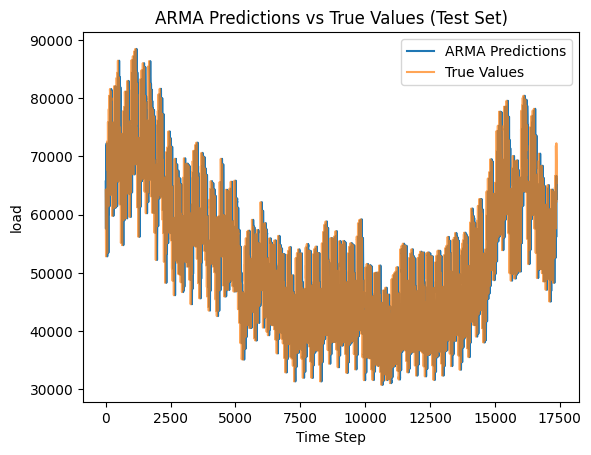

In [8]:
plt.plot(y_pred_arma_test, label='ARMA Predictions')
plt.plot(y_test_arima, label='True Values', alpha=0.7) 
plt.legend() 
plt.title("ARMA Predictions vs True Values (Test Set)") 
plt.xlabel("Time Step") 
plt.ylabel(target) 
plt.show()

## FF

Feed-forward network taking lagged consumption and calendar features as inputs. The global version trains a single shared model across all nodes; the local version trains one model per node.

In [9]:
config = f'configs/config_{DATASET}_ff.json'
with open(config, 'r') as f:
    config_dict = json.load(f)

In [10]:
def create_sequences(X, y, mode='train', horizon=48):
    if mode == 'train':
        X_seqs, y_seqs = [], []
        for i in range(len(X)-horizon+1):
            X_seqs.append(X[i])
            y_seqs.append(y[i:i+horizon])
    else:   
        X_seqs, y_seqs = [], []
        for i in range(len(X)-horizon+1):
            X_seqs.append(X[i])
            y_seqs.append(y[i:i+horizon])
    return np.stack(X_seqs), np.stack(y_seqs)

def fit_global_scaler(datasets_train):
    """
    Fit a global MinMaxScaler across ALL regions/nodes (only on TRAIN).

    Args:
        datasets_train (dict[node] = np.ndarray (n_samples, n_features)):
            Train datasets per node.

    Returns:
        MinMaxScaler fitted on all train data.
    """
    scaler = MinMaxScaler()
    all_train = np.concatenate([arr.reshape(-1, arr.shape[-1]) for arr in datasets_train.values()], axis=0)
    scaler.fit(all_train)
    return scaler


def scale_with_global(scaler, datasets):
    """
    Apply the fitted global scaler to datasets (dict of regions).

    Args:
        scaler (MinMaxScaler): fitted global scaler
        datasets (dict[node] = np.ndarray (n_samples, n_features)): data to transform

    Returns:
        dict[node] = scaled np.ndarray
    """
    scaled = {}
    for node, arr in datasets.items():
        scaled[node] = scaler.transform(arr.reshape(-1, arr.shape[-1]))
    return scaled

def plot_errors(err_train, err_val, err_test, metric="mape"):
    """
    Plot side-by-side bar charts of a chosen error metric for train, validation, and test splits.

    This function creates a 1x3 Matplotlib figure with a shared y-axis, where each subplot
    shows the per-node values of the specified error metric from the corresponding DataFrame.
    The DataFrame index is used as x-axis categories (nodes), and the y-axis label is the
    uppercased metric name. The figure layout is tightened and displayed immediately.

    Parameters
    ----------
    err_train : pandas.DataFrame
        DataFrame of node-level error metrics for the training split. Must contain a column
        named by `metric`; the index provides node labels.
    err_val : pandas.DataFrame
        DataFrame of node-level error metrics for the validation split. Must contain a column
        named by `metric`; the index provides node labels.
    err_test : pandas.DataFrame
        DataFrame of node-level error metrics for the test split. Must contain a column
        named by `metric`; the index provides node labels.
    metric : str, optional
        Name of the error metric column to plot (e.g., "mape", "mae", "rmse"), by default "mape".

    Returns
    -------
    None
        Displays the figure and does not return anything.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharey=True)
    for ax, df, title in zip(axes, [err_train, err_val, err_test], ["Train", "Validation", "Test"]):
        df[metric].plot(kind="bar", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Node")
        ax.set_ylabel(metric.upper())
    plt.tight_layout()
    plt.show()

features = graph_dataset_train.features
target = graph_dataset_train.target
forecast_horizon = OUT_CHANNELS

def inv_transform_nodes(y_stacked, nodes, scaler_Y_node):
    """Inverse-transform (num_nodes * n_per_node, H) using per-node scalers."""
    n_per_node = y_stacked.shape[0] // len(nodes)
    result = np.zeros_like(y_stacked, dtype=float)
    for j, node in enumerate(nodes):
        result[j*n_per_node:(j+1)*n_per_node] = scaler_Y_node[node].inverse_transform(
            y_stacked[j*n_per_node:(j+1)*n_per_node]
        )
    return result

def eval_test_day_jump(preds, targets, horizon=OUT_CHANNELS):
    """Evaluate test metrics on non-overlapping origins (stride=horizon)."""
    p = np.asarray(preds)
    t = np.asarray(targets)
    if p.shape != t.shape:
        raise ValueError(f"Shape mismatch: preds={p.shape}, targets={t.shape}")

    if p.ndim == 1:
        # Already one prediction per instant (no overlapping windows)
        p_eval, t_eval = p, t
    elif p.ndim == 2:
        idx = np.arange(0, p.shape[0], horizon)
        p_eval = p[idx].reshape(-1)
        t_eval = t[idx].reshape(-1)
    else:
        raise ValueError(f"Unsupported ndim={p.ndim} for day-jump evaluation")

    rmse = RMSE(preds=p_eval, targets=t_eval)
    mape = 100 * MAPE(preds=p_eval, targets=t_eval)
    return rmse, mape


In [11]:
X_train_node = {node: [] for node in data.nodes}
y_train_node = {node: [] for node in data.nodes}
X_val_node = {node: [] for node in data.nodes}
y_val_node = {node: [] for node in data.nodes}
X_test_node = {node: [] for node in data.nodes}
y_test_node = {node: [] for node in data.nodes}

X_train_all = []
y_train_all = []

for node in data.nodes:
    train_r = data.df_train[data.df_train[data.node_var] == node].reset_index(drop=True)[features].values
    y_train_r = data.df_train[data.df_train[data.node_var] == node].reset_index(drop=True)[[target]].values

    X_train_all.append(train_r)
    y_train_all.append(y_train_r)

X_train_all = np.concatenate(X_train_all, axis=0)
y_train_all = np.concatenate(y_train_all, axis=0)

global_scalerX = MinMaxScaler().fit(X_train_all)  # global fallback
global_scalerY = MinMaxScaler().fit(y_train_all)  # global fallback

# Per-node scalers (nodewise + channelwise, as in the paper)
scaler_X_node = {}
scaler_Y_node = {}

for node in data.nodes:
    train_r = data.df_train[data.df_train[data.node_var] == node].reset_index(drop=True)[features].values
    val_r   = data.df_val[data.df_val[data.node_var] == node].reset_index(drop=True)[features].values
    test_r  = data.df_test[data.df_test[data.node_var] == node].reset_index(drop=True)[features].values

    y_train_r = data.df_train[data.df_train[data.node_var] == node].reset_index(drop=True)[[target]].values
    y_val_r   = data.df_val[data.df_val[data.node_var] == node].reset_index(drop=True)[[target]].values
    y_test_r  = data.df_test[data.df_test[data.node_var] == node].reset_index(drop=True)[[target]].values

    scaler_X_node[node] = MinMaxScaler().fit(train_r)
    scaler_Y_node[node] = MinMaxScaler().fit(y_train_r)

    train_r_scaled = scaler_X_node[node].transform(train_r)
    val_r_scaled   = scaler_X_node[node].transform(val_r)
    test_r_scaled  = scaler_X_node[node].transform(test_r)

    y_train_r_scaled = scaler_Y_node[node].transform(y_train_r)
    y_val_r_scaled   = scaler_Y_node[node].transform(y_val_r)
    y_test_r_scaled  = scaler_Y_node[node].transform(y_test_r)

    X_train_seq, y_train_seq = create_sequences(train_r_scaled, y_train_r_scaled, mode='train', horizon=forecast_horizon)
    X_val_seq, y_val_seq     = create_sequences(val_r_scaled, y_val_r_scaled, mode='test', horizon=forecast_horizon)
    X_test_seq, y_test_seq   = create_sequences(test_r_scaled, y_test_r_scaled, mode='test', horizon=forecast_horizon)

    X_train_node[node] = torch.tensor(X_train_seq, dtype=torch.float32).reshape(-1, len(features))
    y_train_node[node] = torch.tensor(y_train_seq, dtype=torch.float32).reshape(-1, forecast_horizon)
    X_val_node[node]   = torch.tensor(X_val_seq, dtype=torch.float32).reshape(-1, len(features))
    y_val_node[node]   = torch.tensor(y_val_seq, dtype=torch.float32).reshape(-1, forecast_horizon)
    X_test_node[node]  = torch.tensor(X_test_seq, dtype=torch.float32).reshape(-1, len(features))
    y_test_node[node]  = torch.tensor(y_test_seq, dtype=torch.float32).reshape(-1, forecast_horizon)


### Global (bottom)

A single FF model trained on the pooled data from all nodes. Node-level predictions are summed to obtain the aggregate forecast.

In [12]:
# Global Feed-Forward Neural Network (trained on node features, predictions aggregated)
if TRAIN:
    import copy
    import time

    print("\n" + "=" * 60)
    print("Training Global Feed-Forward Network (Node Input -> Aggregated Output)")
    print("=" * 60)

    # Use node-wise sequences already created
    num_nodes = len(data.nodes)
    num_features = len(features)

    # Concatenate all nodes into a single dataset
    X_train_stacked = np.concatenate([X_train_node[node] for node in data.nodes], axis=0)
    y_train_stacked = np.concatenate([y_train_node[node] for node in data.nodes], axis=0)
    X_val_stacked = np.concatenate([X_val_node[node] for node in data.nodes], axis=0)
    y_val_stacked = np.concatenate([y_val_node[node] for node in data.nodes], axis=0)
    X_test_stacked = np.concatenate([X_test_node[node] for node in data.nodes], axis=0)
    y_test_stacked = np.concatenate([y_test_node[node] for node in data.nodes], axis=0)

    print(f"Node-wise FF inputs: {num_nodes} nodes x {num_features} features")
    print(f"Stacked shapes - Train: {X_train_stacked.shape}, Val: {X_val_stacked.shape}, Test: {X_test_stacked.shape}")

    # Keep data on CPU and stream mini-batches to device for faster/safer loading
    X_train_global_ff = torch.as_tensor(X_train_stacked, dtype=torch.float32)
    y_train_global_ff = torch.as_tensor(y_train_stacked, dtype=torch.float32).reshape(-1, OUT_CHANNELS)
    X_val_global_ff = torch.as_tensor(X_val_stacked, dtype=torch.float32)
    y_val_global_ff = torch.as_tensor(y_val_stacked, dtype=torch.float32).reshape(-1, OUT_CHANNELS)
    X_test_global_ff = torch.as_tensor(X_test_stacked, dtype=torch.float32)
    y_test_global_ff = torch.as_tensor(y_test_stacked, dtype=torch.float32).reshape(-1, OUT_CHANNELS)

    use_cuda = DEVICE.type == "cuda"

    # ---------------------------------------------------------------------
    # Very light HPO on a subset (fast random search)
    # ---------------------------------------------------------------------
    LIGHT_HPO_FF = True
    FF_HPO_TRIALS = 6
    FF_HPO_EPOCHS = 5
    FF_HPO_TRAIN_MAX = 120000
    FF_HPO_VAL_MAX = 40000

    ff_default_params = {
        'hidden_channels': 300,
        'num_layers': 3,
        'learning_rate': 1e-3,
        'batch_size': 2048 if use_cuda else 512,
    }

    global_ff_params = {
        **ff_default_params,
        'n_epochs': 150,
        'patience': 12,
    }

    if LIGHT_HPO_FF:
        print("\nRunning light FF HPO...")

        rng = np.random.default_rng(42)
        train_idx = rng.choice(
            X_train_global_ff.shape[0],
            size=min(FF_HPO_TRAIN_MAX, X_train_global_ff.shape[0]),
            replace=False,
        )
        val_idx = rng.choice(
            X_val_global_ff.shape[0],
            size=min(FF_HPO_VAL_MAX, X_val_global_ff.shape[0]),
            replace=False,
        )

        Xtr_hpo = X_train_global_ff[train_idx]
        ytr_hpo = y_train_global_ff[train_idx]
        Xva_hpo = X_val_global_ff[val_idx].to(DEVICE, non_blocking=use_cuda)
        yva_hpo = y_val_global_ff[val_idx].to(DEVICE, non_blocking=use_cuda)

        candidate_space = {
            'hidden_channels': [128, 192, 256, 320],
            'num_layers': [2, 3],
            'learning_rate': [3e-4, 1e-3, 2e-3],
            'batch_size': [1024, 2048, 4096] if use_cuda else [256, 512, 1024],
        }

        best_cfg = None
        best_cfg_rmse = float('inf')

        for t in range(FF_HPO_TRIALS):
            cfg = {
                'hidden_channels': int(rng.choice(candidate_space['hidden_channels'])),
                'num_layers': int(rng.choice(candidate_space['num_layers'])),
                'learning_rate': float(rng.choice(candidate_space['learning_rate'])),
                'batch_size': int(rng.choice(candidate_space['batch_size'])),
            }

            hpo_model = FF(
                in_channels=num_features,
                num_layers=cfg['num_layers'],
                hidden_channels=cfg['hidden_channels'],
                out_channels=OUT_CHANNELS,
            ).to(DEVICE)

            if use_cuda and hasattr(torch, "set_float32_matmul_precision"):
                torch.set_float32_matmul_precision("high")

            hpo_opt = torch.optim.Adam(hpo_model.parameters(), lr=cfg['learning_rate'])
            hpo_loss = torch.nn.MSELoss().to(DEVICE)
            hpo_loader = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(Xtr_hpo, ytr_hpo),
                shuffle=True,
                batch_size=cfg['batch_size'],
                num_workers=2 if use_cuda else 0,
                pin_memory=use_cuda,
                persistent_workers=use_cuda,
            )

            hpo_scaler = torch.amp.GradScaler("cuda") if use_cuda else None
            hpo_model.train()
            for _ in range(FF_HPO_EPOCHS):
                for xb, yb in hpo_loader:
                    xb = xb.to(DEVICE, non_blocking=use_cuda)
                    yb = yb.to(DEVICE, non_blocking=use_cuda)
                    hpo_opt.zero_grad(set_to_none=True)

                    if use_cuda:
                        with torch.autocast(device_type="cuda", dtype=torch.float16):
                            yp = hpo_model(xb)
                            ls = hpo_loss(yp, yb)
                        hpo_scaler.scale(ls).backward()
                        hpo_scaler.step(hpo_opt)
                        hpo_scaler.update()
                    else:
                        yp = hpo_model(xb)
                        ls = hpo_loss(yp, yb)
                        ls.backward()
                        hpo_opt.step()

            hpo_model.eval()
            with torch.no_grad():
                val_pred = hpo_model(Xva_hpo)
                val_rmse_trial = torch.sqrt(hpo_loss(val_pred, yva_hpo)).item()

            print(f"  Trial {t + 1}/{FF_HPO_TRIALS} -> RMSE={val_rmse_trial:.6f} | cfg={cfg}")
            if val_rmse_trial < best_cfg_rmse:
                best_cfg_rmse = val_rmse_trial
                best_cfg = cfg

        if best_cfg is not None:
            global_ff_params.update(best_cfg)
            print(f"Selected FF params from light HPO: {best_cfg} (RMSE={best_cfg_rmse:.6f})")

    # ---------------------------------------------------------------------
    # Full training with selected params
    # ---------------------------------------------------------------------
    global_ff_model = FF(
        in_channels=num_features,
        num_layers=global_ff_params['num_layers'],
        hidden_channels=global_ff_params['hidden_channels'],
        out_channels=OUT_CHANNELS,
    ).to(DEVICE)

    if use_cuda and hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")

    if use_cuda and hasattr(torch, "compile"):
        try:
            global_ff_model = torch.compile(global_ff_model)
        except Exception as err:
            print(f"torch.compile skipped: {err}")

    optimizer = torch.optim.Adam(global_ff_model.parameters(), lr=global_ff_params['learning_rate'])
    loss_fn = torch.nn.MSELoss().to(DEVICE)

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train_global_ff, y_train_global_ff),
        shuffle=True,
        batch_size=global_ff_params['batch_size'],
        num_workers=4 if use_cuda else 0,
        pin_memory=use_cuda,
        persistent_workers=use_cuda,
        drop_last=False,
    )

    best_val_rmse = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    scaler = torch.amp.GradScaler("cuda") if use_cuda else None
    val_x_device = X_val_global_ff.to(DEVICE, non_blocking=use_cuda)
    val_y_device = y_val_global_ff.to(DEVICE, non_blocking=use_cuda)

    t0 = time.time()
    for epoch in tqdm(range(global_ff_params['n_epochs']), desc="Global FF training"):
        global_ff_model.train()
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE, non_blocking=use_cuda)
            y_batch = y_batch.to(DEVICE, non_blocking=use_cuda)

            optimizer.zero_grad(set_to_none=True)

            if use_cuda:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    y_pred = global_ff_model(X_batch)
                    loss = loss_fn(y_pred, y_batch)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                y_pred = global_ff_model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                loss.backward()
                optimizer.step()

        global_ff_model.eval()
        with torch.no_grad():
            y_pred_val = global_ff_model(val_x_device)
            val_rmse = torch.sqrt(loss_fn(y_pred_val, val_y_device)).item()

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_state = copy.deepcopy(global_ff_model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= global_ff_params['patience']:
                print(f"Early stopping at epoch {epoch + 1} (best val RMSE={best_val_rmse:.6f})")
                break

    print(f"Global FF training time: {time.time() - t0:.1f}s")

    global_ff_model.load_state_dict(best_model_state)
    global_ff_model.eval()

    with torch.no_grad():
        train_x_device = X_train_global_ff.to(DEVICE, non_blocking=use_cuda)
        test_x_device = X_test_global_ff.to(DEVICE, non_blocking=use_cuda)

        y_pred_train_ff_scaled = global_ff_model(train_x_device).cpu().numpy()
        y_pred_val_ff_scaled = global_ff_model(val_x_device).cpu().numpy()
        y_pred_test_ff_scaled = global_ff_model(test_x_device).cpu().numpy()

    n_train_per_node = y_pred_train_ff_scaled.shape[0] // num_nodes
    n_val_per_node = y_pred_val_ff_scaled.shape[0] // num_nodes
    n_test_per_node = y_pred_test_ff_scaled.shape[0] // num_nodes

    y_pred_train_nodes = y_pred_train_ff_scaled.reshape(num_nodes, n_train_per_node, OUT_CHANNELS)
    y_pred_val_nodes = y_pred_val_ff_scaled.reshape(num_nodes, n_val_per_node, OUT_CHANNELS)
    y_pred_test_nodes = y_pred_test_ff_scaled.reshape(num_nodes, n_test_per_node, OUT_CHANNELS)

    y_true_train_nodes = y_train_stacked.reshape(num_nodes, n_train_per_node, OUT_CHANNELS)
    y_true_val_nodes = y_val_stacked.reshape(num_nodes, n_val_per_node, OUT_CHANNELS)
    y_true_test_nodes = y_test_stacked.reshape(num_nodes, n_test_per_node, OUT_CHANNELS)

    nodes_list = list(data.nodes)
    y_pred_train_nodes_inv = np.stack(
        [scaler_Y_node[n].inverse_transform(y_pred_train_nodes[j]) for j, n in enumerate(nodes_list)]
    )
    y_pred_val_nodes_inv = np.stack(
        [scaler_Y_node[n].inverse_transform(y_pred_val_nodes[j]) for j, n in enumerate(nodes_list)]
    )
    y_pred_test_nodes_inv = np.stack(
        [scaler_Y_node[n].inverse_transform(y_pred_test_nodes[j]) for j, n in enumerate(nodes_list)]
    )
    y_true_train_nodes_inv = np.stack(
        [scaler_Y_node[n].inverse_transform(y_true_train_nodes[j]) for j, n in enumerate(nodes_list)]
    )
    y_true_val_nodes_inv = np.stack(
        [scaler_Y_node[n].inverse_transform(y_true_val_nodes[j]) for j, n in enumerate(nodes_list)]
    )
    y_true_test_nodes_inv = np.stack(
        [scaler_Y_node[n].inverse_transform(y_true_test_nodes[j]) for j, n in enumerate(nodes_list)]
    )

    y_pred_train_ff_mat = y_pred_train_nodes_inv.sum(axis=0)
    y_pred_val_ff_mat = y_pred_val_nodes_inv.sum(axis=0)
    y_pred_test_ff_mat = y_pred_test_nodes_inv.sum(axis=0)

    y_pred_train_ff = y_pred_train_ff_mat.ravel()
    y_pred_val_ff = y_pred_val_ff_mat.ravel()
    y_pred_test_ff = y_pred_test_ff_mat.ravel()

    y_true_train_ff_mat = y_true_train_nodes_inv.sum(axis=0)
    y_true_val_ff_mat = y_true_val_nodes_inv.sum(axis=0)
    y_true_test_ff_mat = y_true_test_nodes_inv.sum(axis=0)

    y_true_train_ff = y_true_train_ff_mat.ravel()
    y_true_val_ff = y_true_val_ff_mat.ravel()
    y_true_test_ff = y_true_test_ff_mat.ravel()

    ff_train_rmse = RMSE(preds=y_pred_train_ff, targets=y_true_train_ff)
    ff_train_mape = 100 * MAPE(preds=y_pred_train_ff, targets=y_true_train_ff)
    ff_val_rmse = RMSE(preds=y_pred_val_ff, targets=y_true_val_ff)
    ff_val_mape = 100 * MAPE(preds=y_pred_val_ff, targets=y_true_val_ff)
    ff_test_rmse = RMSE(preds=y_pred_test_ff, targets=y_true_test_ff)
    ff_test_mape = 100 * MAPE(preds=y_pred_test_ff, targets=y_true_test_ff)

    print(f"\nGlobal FF (Node Features) | Train: RMSE={ff_train_rmse:.4f}, MAPE={ff_train_mape:.4f}%")
    print(f"Global FF (Node Features) | Val:   RMSE={ff_val_rmse:.4f}, MAPE={ff_val_mape:.4f}%")
    print(f"Global FF (Node Features) | Test:  RMSE={ff_test_rmse:.4f}, MAPE={ff_test_mape:.4f}%")

    print(f"Global FF aggregated output shape - Train: {y_pred_train_ff.shape}, Val: {y_pred_val_ff.shape}, Test: {y_pred_test_ff.shape}")


Training Global Feed-Forward Network (Node Input -> Aggregated Output)
Node-wise FF inputs: 12 nodes x 125 features
Stacked shapes - Train: (627276, 125), Val: (207948, 125), Test: (207948, 125)

Running light FF HPO...
  Trial 1/6 -> RMSE=0.040464 | cfg={'hidden_channels': 320, 'num_layers': 3, 'learning_rate': 0.0003, 'batch_size': 1024}
  Trial 2/6 -> RMSE=0.045114 | cfg={'hidden_channels': 256, 'num_layers': 2, 'learning_rate': 0.0003, 'batch_size': 1024}
  Trial 3/6 -> RMSE=0.037815 | cfg={'hidden_channels': 192, 'num_layers': 2, 'learning_rate': 0.0003, 'batch_size': 256}
  Trial 4/6 -> RMSE=0.036850 | cfg={'hidden_channels': 256, 'num_layers': 3, 'learning_rate': 0.002, 'batch_size': 256}
  Trial 5/6 -> RMSE=0.039023 | cfg={'hidden_channels': 320, 'num_layers': 2, 'learning_rate': 0.0003, 'batch_size': 512}
  Trial 6/6 -> RMSE=0.036045 | cfg={'hidden_channels': 256, 'num_layers': 3, 'learning_rate': 0.001, 'batch_size': 512}
Selected FF params from light HPO: {'hidden_channels'

Global FF training:  35%|███▍      | 52/150 [02:49<05:19,  3.26s/it]

Early stopping at epoch 53 (best val RMSE=0.028018)
Global FF training time: 169.5s



Global FF (Node Features) | Train: RMSE=980.7766, MAPE=1.2680%
Global FF (Node Features) | Val:   RMSE=1245.0427, MAPE=1.5264%
Global FF (Node Features) | Test:  RMSE=1381.6571, MAPE=1.6380%
Global FF aggregated output shape - Train: (2509104,), Val: (831792,), Test: (831792,)


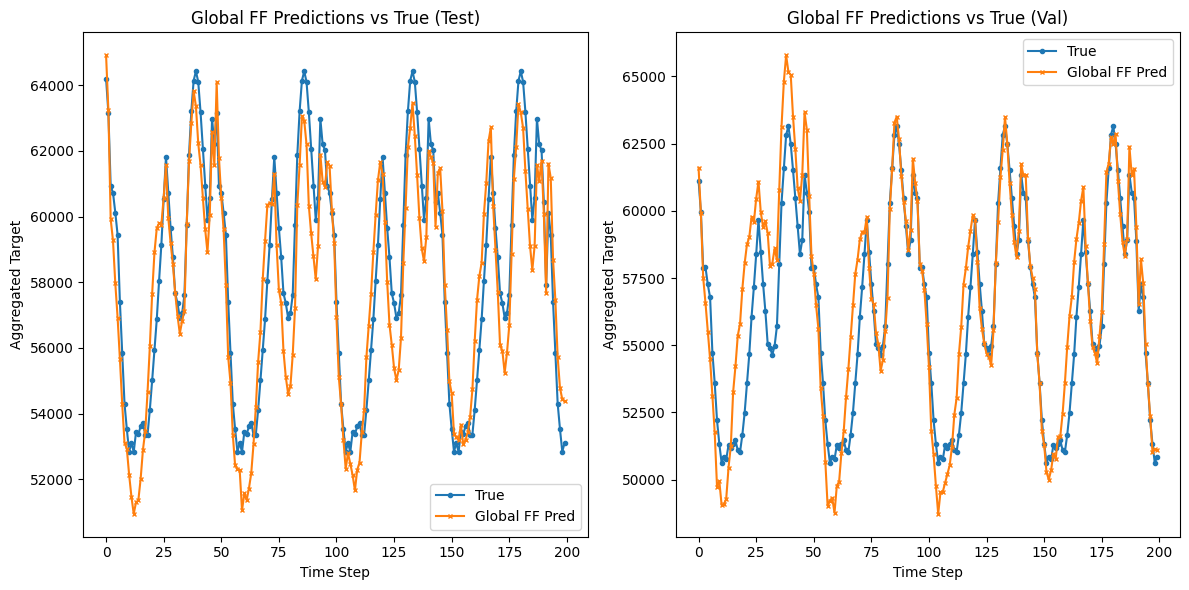

In [13]:
# Plot predictions for global FF
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(y_true_test_ff[:200], label="True", marker='o', markersize=3)
plt.plot(y_pred_test_ff[:200], label="Global FF Pred", marker='x', markersize=3)
plt.title("Global FF Predictions vs True (Test)")
plt.xlabel("Time Step")
plt.ylabel("Aggregated Target")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(y_true_val_ff[:200], label="True", marker='o', markersize=3)
plt.plot(y_pred_val_ff[:200], label="Global FF Pred", marker='x', markersize=3)
plt.title("Global FF Predictions vs True (Val)")
plt.xlabel("Time Step")
plt.ylabel("Aggregated Target")
plt.legend()
plt.tight_layout()
plt.show()

### Local (bottom)

One FF model per node. Predictions are aggregated bottom-up.

100%|██████████| 12/12 [01:44<00:00,  8.69s/it]


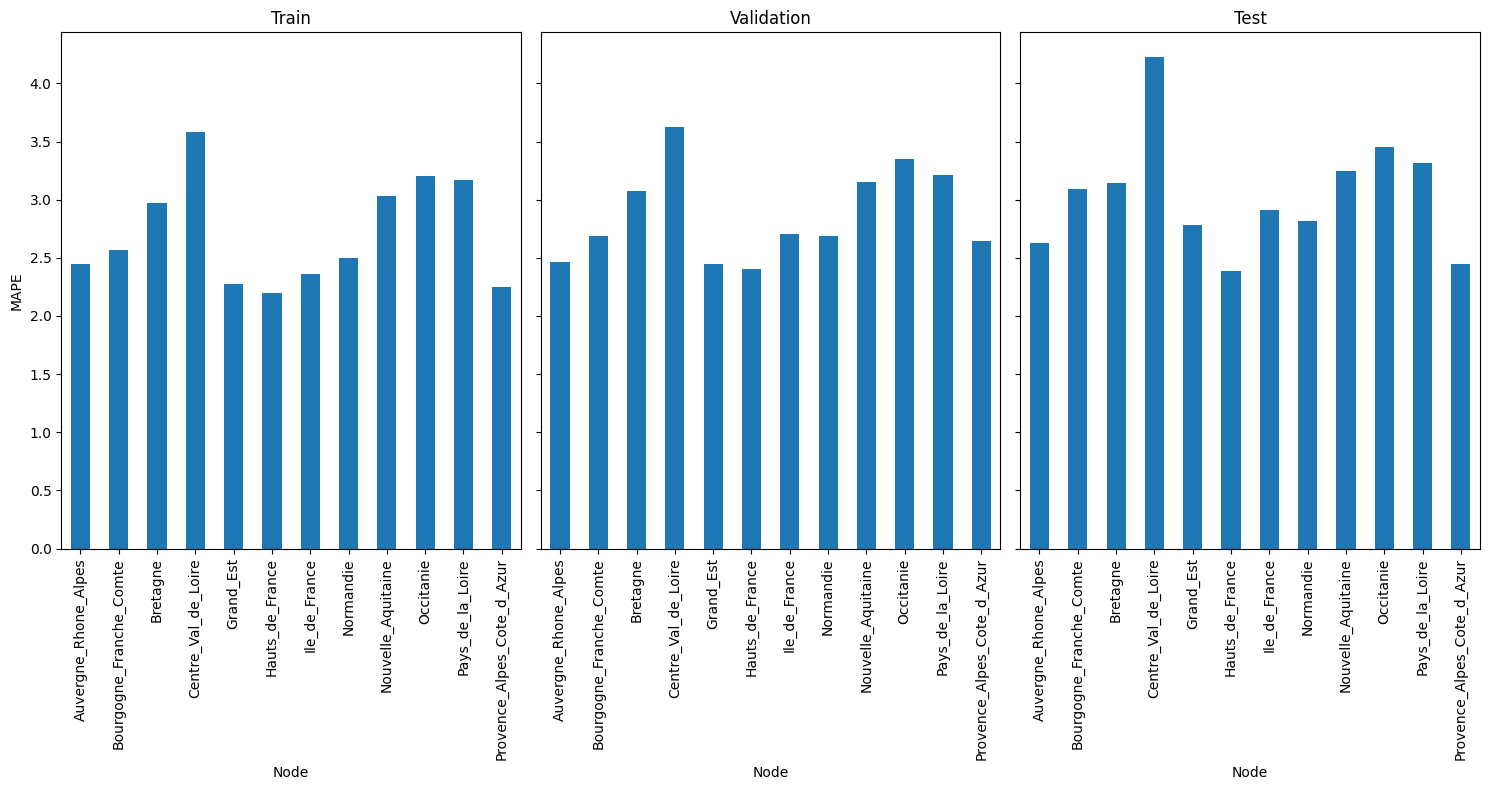

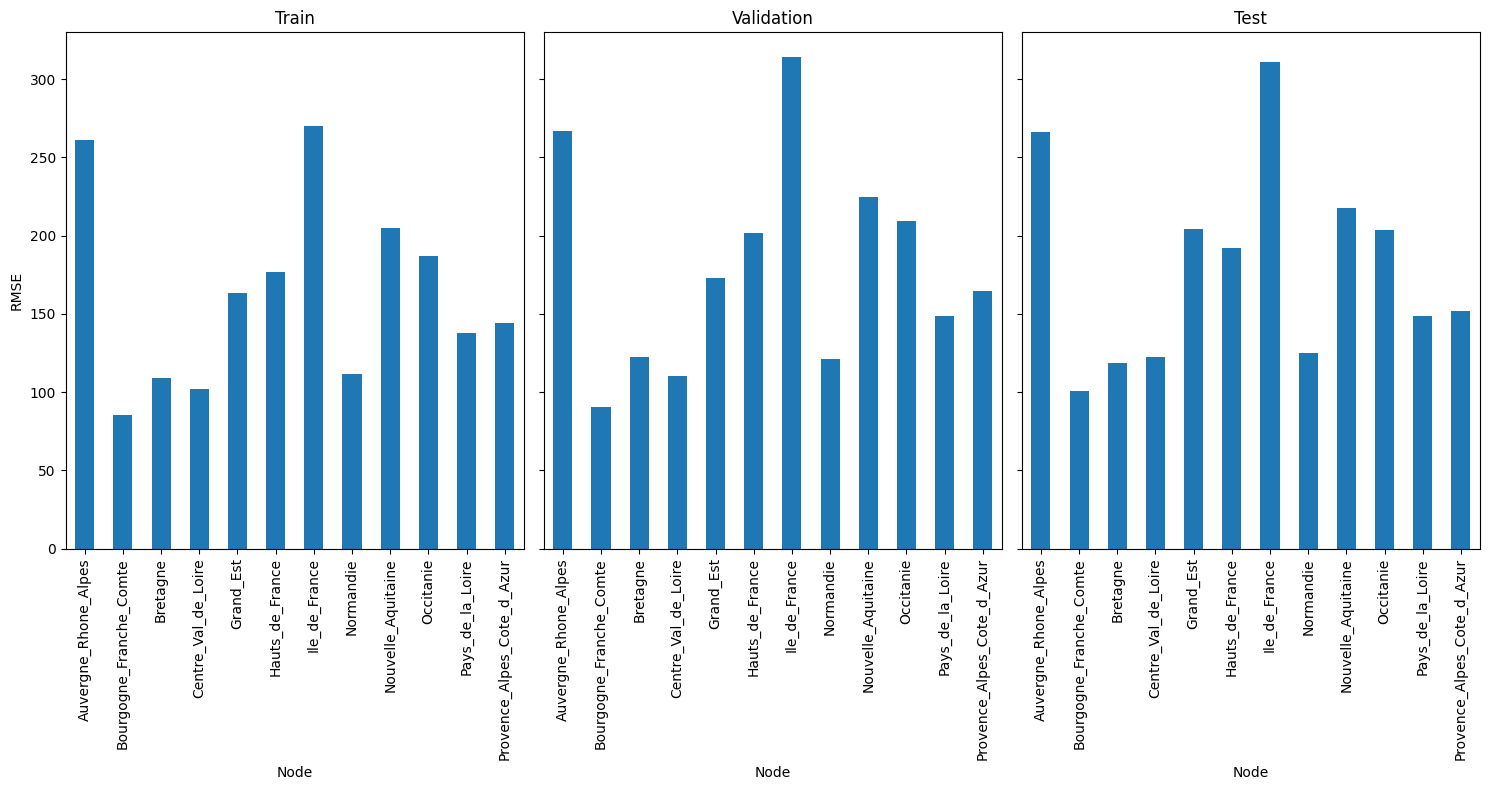

In [14]:
n_epochs = 10

# Very light HPO controls for local FF
LIGHT_HPO_LOCAL_FF = True
LOCAL_FF_HPO_TRIALS = 3
LOCAL_FF_HPO_EPOCHS = 3
LOCAL_FF_HPO_TRAIN_MAX = 20000
LOCAL_FF_HPO_VAL_MAX = 6000

if DATASET == 'weave':
    nodes = [node for node in data.nodes if node != '06-06 st andrews road n/b_020-STOKE PLACE']
else:
    nodes = data.nodes

results_train = {node: {} for node in nodes}
results_val = {node: {} for node in nodes}
results_test = {node: {} for node in nodes}

individual_preds_train = {}
individual_preds_val = {}
individual_preds_test = {}

individual_true_train = {}
individual_true_val = {}
individual_true_test = {}

if TRAIN:
    rng = np.random.default_rng(42)

    for region in tqdm(nodes):
        default_params = {
            'hidden_channels': 192,
            'lr': 1e-3,
            'num_layers': 2,
            'batch_size': 512,
        }
        params = config_dict.get(region, {}).get('params', default_params)
        hidden_channels = int(params['hidden_channels'])
        learning_rate = float(params['lr'])
        num_layers = int(params['num_layers'])
        batch_size = int(params['batch_size'])

        X_train = X_train_node[region].to(DEVICE)
        y_train = y_train_node[region].to(DEVICE)
        X_val = X_val_node[region].to(DEVICE)
        y_val = y_val_node[region].to(DEVICE)
        X_test = X_test_node[region].to(DEVICE)
        y_test = y_test_node[region].to(DEVICE)
        scalerY = scaler_Y_node[region]

        if LIGHT_HPO_LOCAL_FF:
            tr_n = min(LOCAL_FF_HPO_TRAIN_MAX, X_train.shape[0])
            va_n = min(LOCAL_FF_HPO_VAL_MAX, X_val.shape[0])
            tr_idx = torch.as_tensor(rng.choice(X_train.shape[0], size=tr_n, replace=False), device=DEVICE)
            va_idx = torch.as_tensor(rng.choice(X_val.shape[0], size=va_n, replace=False), device=DEVICE)
            Xtr_hpo, ytr_hpo = X_train[tr_idx], y_train[tr_idx]
            Xva_hpo, yva_hpo = X_val[va_idx], y_val[va_idx]

            candidate_space = {
                'hidden_channels': [128, 192, 256],
                'num_layers': [2, 3],
                'lr': [3e-4, 1e-3, 2e-3],
                'batch_size': [256, 512, 1024],
            }

            best_cfg = None
            best_cfg_rmse = float('inf')

            for _ in range(LOCAL_FF_HPO_TRIALS):
                cfg = {
                    'hidden_channels': int(rng.choice(candidate_space['hidden_channels'])),
                    'num_layers': int(rng.choice(candidate_space['num_layers'])),
                    'lr': float(rng.choice(candidate_space['lr'])),
                    'batch_size': int(rng.choice(candidate_space['batch_size'])),
                }

                hpo_model = FF(
                    in_channels=X_train.shape[-1],
                    num_layers=cfg['num_layers'],
                    hidden_channels=cfg['hidden_channels'],
                    out_channels=OUT_CHANNELS,
                ).to(DEVICE)
                hpo_opt = torch.optim.Adam(hpo_model.parameters(), lr=cfg['lr'])
                hpo_loss = torch.nn.MSELoss().to(DEVICE)
                hpo_loader = torch.utils.data.DataLoader(
                    torch.utils.data.TensorDataset(Xtr_hpo, ytr_hpo),
                    shuffle=True,
                    batch_size=cfg['batch_size'],
                )

                hpo_model.train()
                for _ in range(LOCAL_FF_HPO_EPOCHS):
                    for xb, yb in hpo_loader:
                        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                        yp = hpo_model(xb)
                        ls = hpo_loss(yp, yb)
                        hpo_opt.zero_grad(set_to_none=True)
                        ls.backward()
                        hpo_opt.step()

                hpo_model.eval()
                with torch.no_grad():
                    va_pred = hpo_model(Xva_hpo)
                    va_rmse = np.sqrt(hpo_loss(va_pred, yva_hpo).item())

                if va_rmse < best_cfg_rmse:
                    best_cfg_rmse = va_rmse
                    best_cfg = cfg

            if best_cfg is not None:
                hidden_channels = best_cfg['hidden_channels']
                learning_rate = best_cfg['lr']
                num_layers = best_cfg['num_layers']
                batch_size = best_cfg['batch_size']

        model = FF(
            in_channels=X_train.shape[-1],
            num_layers=num_layers,
            hidden_channels=hidden_channels,
            out_channels=OUT_CHANNELS,
        ).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        loss_fn = torch.nn.MSELoss().to(DEVICE)
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_train, y_train),
            shuffle=True,
            batch_size=batch_size,
        )

        best_val_rmse = float('inf')
        best_model_state = None
        for epoch in tqdm(range(n_epochs), leave=False):
            model.train()
            for X_batch, y_batch in loader:
                X_batch, y_batch = X_batch.float().to(DEVICE), y_batch.to(DEVICE)
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                y_pred_val = model(X_val)
                val_rmse = np.sqrt(loss_fn(y_pred_val, y_val).item())
                if val_rmse < best_val_rmse:
                    best_val_rmse = val_rmse
                    best_model_state = model.state_dict()

        model.eval()
        model.load_state_dict(best_model_state)

        y_pred_train = model(X_train)
        y_pred_train, y_true_train = scalerY.inverse_transform(y_pred_train.cpu().detach().numpy()), scalerY.inverse_transform(y_train.cpu().detach().numpy())
        individual_preds_train[region] = y_pred_train
        individual_true_train[region] = y_true_train
        results_train[region]['mape'] = 100 * MAPE(preds=y_pred_train, targets=y_true_train)
        results_train[region]['rmse'] = RMSE(preds=y_pred_train, targets=y_true_train)

        y_pred_val = model(X_val)
        y_pred_val, y_true_val = scalerY.inverse_transform(y_pred_val.cpu().detach().numpy()), scalerY.inverse_transform(y_val.cpu().detach().numpy())
        individual_preds_val[region] = y_pred_val
        individual_true_val[region] = y_true_val
        results_val[region]['mape'] = 100 * MAPE(preds=y_pred_val, targets=y_true_val)
        results_val[region]['rmse'] = RMSE(preds=y_pred_val, targets=y_true_val)

        y_pred_test = model(X_test)
        y_pred_test, y_true_test = scalerY.inverse_transform(y_pred_test.cpu().detach().numpy()), scalerY.inverse_transform(y_test.cpu().detach().numpy())
        individual_preds_test[region] = y_pred_test
        individual_true_test[region] = y_true_test
        results_test[region]['mape'] = 100 * MAPE(preds=y_pred_test, targets=y_true_test)
        results_test[region]['rmse'] = RMSE(preds=y_pred_test, targets=y_true_test)

    err_train = pd.DataFrame(results_train).T
    err_val = pd.DataFrame(results_val).T
    err_test = pd.DataFrame(results_test).T

    plot_errors(err_train, err_val, err_test, "mape")
    plot_errors(err_train, err_val, err_test, "rmse")

In [15]:
if TRAIN:
    total_preds_train, total_true_train = 0, 0
    total_preds_val, total_true_val = 0, 0
    total_preds_test, total_true_test = 0, 0
    for node in nodes:
        total_preds_train += individual_preds_train[node].ravel()
        total_true_train += individual_true_train[node].ravel()
        total_preds_val += individual_preds_val[node].ravel()
        total_true_val += individual_true_val[node].ravel()
        total_preds_test += individual_preds_test[node].ravel()
        total_true_test += individual_true_test[node].ravel()
    print(100*MAPE(preds=total_preds_train, targets=total_true_train), RMSE(preds=total_preds_train, targets=total_true_train))
    print(100*MAPE(preds=total_preds_val, targets=total_true_val), RMSE(preds=total_preds_val, targets=total_true_val))
    total_preds_test_mat = 0
    total_true_test_mat = 0
    for node in nodes:
        total_preds_test_mat += individual_preds_test[node]
        total_true_test_mat += individual_true_test[node]
    test_rmse = RMSE(preds=total_preds_test, targets=total_true_test)
    test_mape = 100 * MAPE(preds=total_preds_test, targets=total_true_test)
    print(test_mape, test_rmse)

1.6242365 1325.0686
1.7334893 1429.0615
1.9069089 1519.7113


## XGBoost

Gradient-boosted trees using the same features as the FF baselines.

### Global (bottom)

A single XGBoost model trained on all nodes jointly.

#### Multi-output: $X_h \to y_h$ (H independent models)

In [16]:
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

print("\n" + "="*60)
print("XGBoost Global Baseline (Multi-Output)")
print("="*60)

# Convert torch tensors to numpy
X_train_list = []
y_train_list = []
for node in data.nodes:
    x_np = X_train_node[node].cpu().numpy() if hasattr(X_train_node[node], 'cpu') else np.array(X_train_node[node])
    y_np = y_train_node[node].cpu().numpy() if hasattr(y_train_node[node], 'cpu') else np.array(y_train_node[node])
    X_train_list.append(x_np)
    y_train_list.append(y_np)

X_val_list = []
y_val_list = []
for node in data.nodes:
    x_np = X_val_node[node].cpu().numpy() if hasattr(X_val_node[node], 'cpu') else np.array(X_val_node[node])
    y_np = y_val_node[node].cpu().numpy() if hasattr(y_val_node[node], 'cpu') else np.array(y_val_node[node])
    X_val_list.append(x_np)
    y_val_list.append(y_np)

X_test_list = []
y_test_list = []
for node in data.nodes:
    x_np = X_test_node[node].cpu().numpy() if hasattr(X_test_node[node], 'cpu') else np.array(X_test_node[node])
    y_np = y_test_node[node].cpu().numpy() if hasattr(y_test_node[node], 'cpu') else np.array(y_test_node[node])
    X_test_list.append(x_np)
    y_test_list.append(y_np)

# Concatenate along batch dimension (keeping all output channels)
X_train_stacked = np.concatenate(X_train_list, axis=0)
y_train_stacked = np.concatenate(y_train_list, axis=0)
X_val_stacked = np.concatenate(X_val_list, axis=0)
y_val_stacked = np.concatenate(y_val_list, axis=0)
X_test_stacked = np.concatenate(X_test_list, axis=0)
y_test_stacked = np.concatenate(y_test_list, axis=0)

print(f"\nStacked shapes (multi-output):")
print(f"  X_train: {X_train_stacked.shape}, y_train: {y_train_stacked.shape}")
print(f"  X_val: {X_val_stacked.shape}, y_val: {y_val_stacked.shape}")
print(f"  X_test: {X_test_stacked.shape}, y_test: {y_test_stacked.shape}")

num_nodes = len(data.nodes)
OUT_CHANNELS = y_train_stacked.shape[1]

# ---------------------------------------------------------------------
# Very light HPO on subset (single target channel)
# ---------------------------------------------------------------------
LIGHT_HPO_XGB = True
XGB_HPO_TRIALS = 10
XGB_HPO_TRAIN_MAX = 120000
XGB_HPO_VAL_MAX = 40000

xgb_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.1,
    'max_depth': 10,
    'min_child_weight': 9.886189229106565,
    'subsample': 0.8929644165419383,
    'colsample_bytree': 0.6933420681040697,
    'reg_alpha': 0.0014783970830547111,
    'reg_lambda': 0.11800510269452669,
    'n_estimators': 280,
    'tree_method': 'hist',
    'random_state': 42,
}

if LIGHT_HPO_XGB:
    print("\nRunning light XGBoost HPO...")
    rng = np.random.default_rng(42)

    tr_idx = rng.choice(
        X_train_stacked.shape[0],
        size=min(XGB_HPO_TRAIN_MAX, X_train_stacked.shape[0]),
        replace=False,
    )
    va_idx = rng.choice(
        X_val_stacked.shape[0],
        size=min(XGB_HPO_VAL_MAX, X_val_stacked.shape[0]),
        replace=False,
    )

    # Tune on a single representative horizon/channel for speed
    tune_channel = OUT_CHANNELS // 2
    Xtr_hpo = X_train_stacked[tr_idx]
    ytr_hpo = y_train_stacked[tr_idx, tune_channel]
    Xva_hpo = X_val_stacked[va_idx]
    yva_hpo = y_val_stacked[va_idx, tune_channel]

    best_rmse = float('inf')
    best_cfg = None

    for t in range(XGB_HPO_TRIALS):
        cfg = {
            'learning_rate': float(rng.choice([0.03, 0.05, 0.1, 0.2])),
            'max_depth': int(rng.choice([4, 6, 8, 10])),
            'min_child_weight': float(rng.choice([1.0, 3.0, 6.0, 10.0])),
            'subsample': float(rng.choice([0.7, 0.85, 1.0])),
            'colsample_bytree': float(rng.choice([0.6, 0.8, 1.0])),
            'reg_alpha': float(rng.choice([0.0, 1e-4, 1e-3, 1e-2])),
            'reg_lambda': float(rng.choice([0.1, 1.0, 5.0, 10.0])),
            'n_estimators': int(rng.choice([120, 180, 260, 340])),
        }

        model_hpo = xgb.XGBRegressor(
            objective='reg:squarederror',
            tree_method='hist',
            random_state=42,
            **cfg,
        )
        model_hpo.fit(
            Xtr_hpo,
            ytr_hpo,
            eval_set=[(Xva_hpo, yva_hpo)],
            verbose=False,
        )

        pred_va = model_hpo.predict(Xva_hpo)
        rmse_va = float(np.sqrt(np.mean((pred_va - yva_hpo) ** 2)))
        print(f"  Trial {t + 1}/{XGB_HPO_TRIALS} -> RMSE={rmse_va:.6f} | cfg={cfg}")

        if rmse_va < best_rmse:
            best_rmse = rmse_va
            best_cfg = cfg

    if best_cfg is not None:
        xgb_params.update(best_cfg)
        print(f"Selected XGB params from light HPO: {best_cfg} (RMSE={best_rmse:.6f})")

# ---------------------------------------------------------------------
# Full training with selected params
# ---------------------------------------------------------------------
print("\nTraining XGBoost (multi-output)...")
xgb_multi = MultiOutputRegressor(xgb.XGBRegressor(**xgb_params), n_jobs=-1)
xgb_multi.fit(X_train_stacked, y_train_stacked, verbose=False)
print("Training complete.")

# Predictions (multi-output)
y_pred_train = xgb_multi.predict(X_train_stacked)
y_pred_val = xgb_multi.predict(X_val_stacked)
y_pred_test = xgb_multi.predict(X_test_stacked)

# Inverse-scale
# Per-node inverse transform (nodewise normalisation per paper)
y_pred_train_inv = inv_transform_nodes(y_pred_train, data.nodes, scaler_Y_node)
y_pred_val_inv   = inv_transform_nodes(y_pred_val,   data.nodes, scaler_Y_node)
y_pred_test_inv  = inv_transform_nodes(y_pred_test,  data.nodes, scaler_Y_node)

y_true_train_inv = inv_transform_nodes(y_train_stacked, data.nodes, scaler_Y_node)
y_true_val_inv   = inv_transform_nodes(y_val_stacked,   data.nodes, scaler_Y_node)
y_true_test_inv  = inv_transform_nodes(y_test_stacked,  data.nodes, scaler_Y_node)

# Reshape back to (num_nodes, T, OUT_CHANNELS) structure
n_train_per_node = y_train_stacked.shape[0] // num_nodes
n_val_per_node = y_val_stacked.shape[0] // num_nodes
n_test_per_node = y_test_stacked.shape[0] // num_nodes

y_pred_train_nodes = y_pred_train_inv.reshape(num_nodes, n_train_per_node, OUT_CHANNELS)
y_pred_val_nodes = y_pred_val_inv.reshape(num_nodes, n_val_per_node, OUT_CHANNELS)
y_pred_test_nodes = y_pred_test_inv.reshape(num_nodes, n_test_per_node, OUT_CHANNELS)

y_true_train_nodes = y_true_train_inv.reshape(num_nodes, n_train_per_node, OUT_CHANNELS)
y_true_val_nodes = y_true_val_inv.reshape(num_nodes, n_val_per_node, OUT_CHANNELS)
y_true_test_nodes = y_true_test_inv.reshape(num_nodes, n_test_per_node, OUT_CHANNELS)

# Aggregate: sum across nodes (axis 0), flatten to get (T * OUT_CHANNELS,)
y_pred_train_agg_mat = y_pred_train_nodes.sum(axis=0)
y_pred_val_agg_mat = y_pred_val_nodes.sum(axis=0)
y_pred_test_agg_mat = y_pred_test_nodes.sum(axis=0)

y_pred_train_agg = y_pred_train_agg_mat.ravel()
y_pred_val_agg = y_pred_val_agg_mat.ravel()
y_pred_test_agg = y_pred_test_agg_mat.ravel()

y_true_train_agg_mat = y_true_train_nodes.sum(axis=0)
y_true_val_agg_mat = y_true_val_nodes.sum(axis=0)
y_true_test_agg_mat = y_true_test_nodes.sum(axis=0)

y_true_train_agg = y_true_train_agg_mat.ravel()
y_true_val_agg = y_true_val_agg_mat.ravel()
y_true_test_agg = y_true_test_agg_mat.ravel()

print(f"\nAggregated shapes (sum across nodes): Train {y_pred_train_agg.shape}, Val {y_pred_val_agg.shape}, Test {y_pred_test_agg.shape}")

# Metrics
xgb_alt_train_rmse = RMSE(preds=y_pred_train_agg, targets=y_true_train_agg)
xgb_alt_train_mape = 100 * MAPE(preds=y_pred_train_agg, targets=y_true_train_agg)

xgb_alt_val_rmse = RMSE(preds=y_pred_val_agg, targets=y_true_val_agg)
xgb_alt_val_mape = 100 * MAPE(preds=y_pred_val_agg, targets=y_true_val_agg)

xgb_alt_test_rmse = RMSE(preds=y_pred_test_agg, targets=y_true_test_agg)
xgb_alt_test_mape = 100 * MAPE(preds=y_pred_test_agg, targets=y_true_test_agg)

print(f"\nXGBoost Global (Multi-Output) | Train: RMSE={xgb_alt_train_rmse:.4f}, MAPE={xgb_alt_train_mape:.4f}%")
print(f"XGBoost Global (Multi-Output) | Val:   RMSE={xgb_alt_val_rmse:.4f}, MAPE={xgb_alt_val_mape:.4f}%")
print(f"XGBoost Global (Multi-Output) | Test:  RMSE={xgb_alt_test_rmse:.4f}, MAPE={xgb_alt_test_mape:.4f}%")


XGBoost Global Baseline (Multi-Output)

Stacked shapes (multi-output):
  X_train: (627276, 125), y_train: (627276, 48)
  X_val: (207948, 125), y_val: (207948, 48)
  X_test: (207948, 125), y_test: (207948, 48)

Running light XGBoost HPO...
  Trial 1/10 -> RMSE=0.034597 | cfg={'learning_rate': 0.2, 'max_depth': 8, 'min_child_weight': 3.0, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.0001, 'reg_lambda': 0.1, 'n_estimators': 260}
  Trial 2/10 -> RMSE=0.042128 | cfg={'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 3.0, 'subsample': 0.7, 'colsample_bytree': 1.0, 'reg_alpha': 0.01, 'reg_lambda': 10.0, 'n_estimators': 120}
  Trial 3/10 -> RMSE=0.035899 | cfg={'learning_rate': 0.2, 'max_depth': 6, 'min_child_weight': 1.0, 'subsample': 0.85, 'colsample_bytree': 0.8, 'reg_alpha': 0.001, 'reg_lambda': 5.0, 'n_estimators': 180}
  Trial 4/10 -> RMSE=0.033880 | cfg={'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 1.0, 'subsample': 0.7, 'colsample_bytree': 1.0, 'reg_

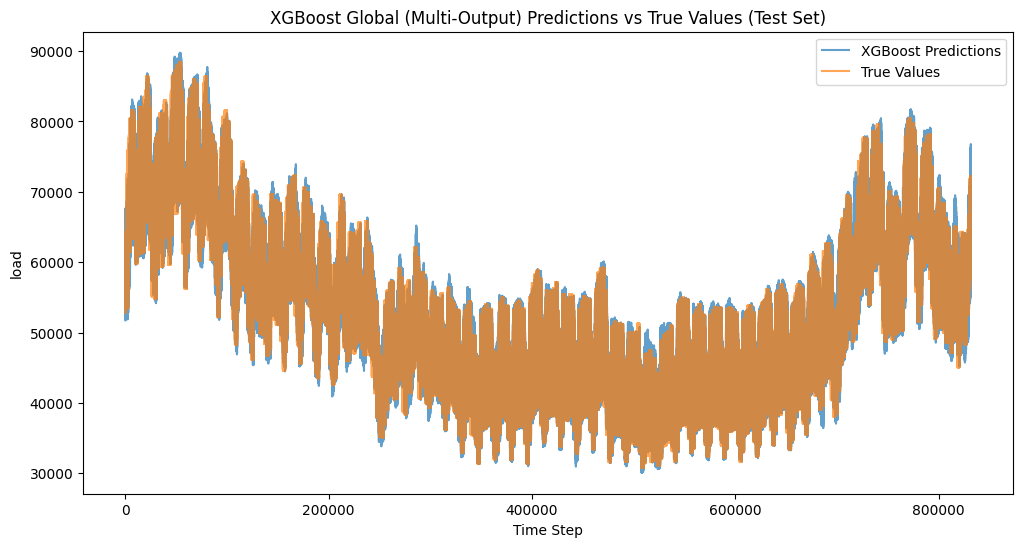

In [17]:
# Plot predictions vs true values for test set
plt.figure(figsize=(12, 6))
plt.plot(y_pred_test_agg, label='XGBoost Predictions', alpha=0.7)
plt.plot(y_true_test_agg, label='True Values', alpha=0.7)
plt.legend()
plt.title("XGBoost Global (Multi-Output) Predictions vs True Values (Test Set)")
plt.xlabel("Time Step")
plt.ylabel(target)
plt.show()

##### Top-down

In [18]:
from sklearn.preprocessing import StandardScaler


def add_horizon_feature_only(X, y):
    """Expand (N, F)->(N*H, F+1) with normalized horizon index."""
    N, F = X.shape
    H = y.shape[1]
    X_rep = np.repeat(X, H, axis=0)
    h = np.tile(np.arange(H), N).reshape(-1, 1).astype(np.float32)
    h_norm = h / H
    X_new = np.concatenate([X_rep, h_norm], axis=1)
    y_new = y.reshape(-1)
    return X_new, y_new


# Build TOP targets in original scale, then scale with a dedicated top scaler
num_nodes = len(data.nodes)

# Shapes from stacked node-level data
n_train_per_node = y_train_stacked.shape[0] // num_nodes
n_val_per_node = y_val_stacked.shape[0] // num_nodes
n_test_per_node = y_test_stacked.shape[0] // num_nodes

# Node-level targets back to original scale
# Per-node inverse transform (nodewise normalisation per paper)
y_train_nodes_inv = inv_transform_nodes(y_train_stacked, data.nodes, scaler_Y_node).reshape(num_nodes, n_train_per_node, OUT_CHANNELS)
y_val_nodes_inv = inv_transform_nodes(y_val_stacked, data.nodes, scaler_Y_node).reshape(num_nodes, n_val_per_node, OUT_CHANNELS)
y_test_nodes_inv = inv_transform_nodes(y_test_stacked, data.nodes, scaler_Y_node).reshape(num_nodes, n_test_per_node, OUT_CHANNELS)

# Top-level targets: aggregate across nodes -> (T, H)
y_train_top = y_train_nodes_inv.sum(axis=0)
y_val_top = y_val_nodes_inv.sum(axis=0)
y_test_top = y_test_nodes_inv.sum(axis=0)

# Scale top targets with train-only statistics
top_scalerY = StandardScaler()
y_train_top_scaled = top_scalerY.fit_transform(y_train_top)
y_val_top_scaled = top_scalerY.transform(y_val_top)
y_test_top_scaled = top_scalerY.transform(y_test_top)

def build_global_features(X_nodes, num_nodes):
    X_nodes = X_nodes.reshape(num_nodes, -1, X_nodes.shape[1])
    # Global top-level covariates: mean over nodes for each timestamp
    return X_nodes.mean(axis=0)

X_train_global = build_global_features(X_train_stacked, num_nodes)
X_val_global = build_global_features(X_val_stacked, num_nodes)
X_test_global = build_global_features(X_test_stacked, num_nodes)

X_train_top_h, y_train_top_h = add_horizon_feature_only(X_train_global, y_train_top_scaled)
X_val_top_h, y_val_top_h = add_horizon_feature_only(X_val_global, y_val_top_scaled)
X_test_top_h, y_test_top_h = add_horizon_feature_only(X_test_global, y_test_top_scaled)

print("\n" + "=" * 60)
print("XGBoost TOP (direct)")
print("=" * 60)

# Very light HPO for top-down model
LIGHT_HPO_XGB_TOP = True
XGB_TOP_HPO_TRIALS = 10
XGB_TOP_HPO_TRAIN_MAX = 150000
XGB_TOP_HPO_VAL_MAX = 50000

xgb_top_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 6,
    'min_child_weight': 5,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'reg_alpha': 1e-3,
    'reg_lambda': 1.0,
    'n_estimators': 600,
    'tree_method': 'hist',
    'random_state': 42,
}

if LIGHT_HPO_XGB_TOP:
    rng = np.random.default_rng(42)
    tr_idx = rng.choice(X_train_top_h.shape[0], size=min(XGB_TOP_HPO_TRAIN_MAX, X_train_top_h.shape[0]), replace=False)
    va_idx = rng.choice(X_val_top_h.shape[0], size=min(XGB_TOP_HPO_VAL_MAX, X_val_top_h.shape[0]), replace=False)

    Xtr_hpo, ytr_hpo = X_train_top_h[tr_idx], y_train_top_h[tr_idx]
    Xva_hpo, yva_hpo = X_val_top_h[va_idx], y_val_top_h[va_idx]

    best_rmse = float('inf')
    best_cfg = None

    for t in range(XGB_TOP_HPO_TRIALS):
        cfg = {
            'learning_rate': float(rng.choice([0.03, 0.05, 0.1, 0.2])),
            'max_depth': int(rng.choice([4, 6, 8])),
            'min_child_weight': float(rng.choice([1.0, 3.0, 6.0, 10.0])),
            'subsample': float(rng.choice([0.7, 0.85, 1.0])),
            'colsample_bytree': float(rng.choice([0.6, 0.8, 1.0])),
            'reg_alpha': float(rng.choice([0.0, 1e-4, 1e-3, 1e-2])),
            'reg_lambda': float(rng.choice([0.1, 1.0, 5.0, 10.0])),
            'n_estimators': int(rng.choice([160, 260, 360, 500])),
        }

        model_hpo = xgb.XGBRegressor(
            objective='reg:squarederror',
            tree_method='hist',
            random_state=42,
            **cfg,
        )
        model_hpo.fit(Xtr_hpo, ytr_hpo, eval_set=[(Xva_hpo, yva_hpo)], verbose=False)
        pred_va = model_hpo.predict(Xva_hpo)
        rmse_va = float(np.sqrt(np.mean((pred_va - yva_hpo) ** 2)))
        if rmse_va < best_rmse:
            best_rmse = rmse_va
            best_cfg = cfg

    if best_cfg is not None:
        xgb_top_params.update(best_cfg)
        print(f"Selected XGB TOP params from light HPO: {best_cfg} (RMSE={best_rmse:.6f})")

xgb_top = xgb.XGBRegressor(**xgb_top_params)
xgb_top.fit(
    X_train_top_h,
    y_train_top_h,
    eval_set=[(X_val_top_h, y_val_top_h)],
    verbose=False,
)

def predict_multi_top(model, X_global, H):
    N = X_global.shape[0]
    X_rep = np.repeat(X_global, H, axis=0)
    h = np.tile(np.arange(H), N).reshape(-1, 1).astype(np.float32)
    h_norm = h / H
    X_h = np.concatenate([X_rep, h_norm], axis=1)
    preds = model.predict(X_h)
    return preds.reshape(N, H)

# Predict directly at TOP level (T, H)
y_pred_train_top_scaled = predict_multi_top(xgb_top, X_train_global, OUT_CHANNELS)
y_pred_val_top_scaled = predict_multi_top(xgb_top, X_val_global, OUT_CHANNELS)
y_pred_test_top_scaled = predict_multi_top(xgb_top, X_test_global, OUT_CHANNELS)

# Back to original MW scale
y_pred_train_top = top_scalerY.inverse_transform(y_pred_train_top_scaled)
y_pred_val_top = top_scalerY.inverse_transform(y_pred_val_top_scaled)
y_pred_test_top = top_scalerY.inverse_transform(y_pred_test_top_scaled)

# Flatten for metric computation over all horizons and timestamps
y_pred_train_h_top_agg = y_pred_train_top.ravel()
y_pred_val_h_top_agg = y_pred_val_top.ravel()
y_pred_test_h_top_agg = y_pred_test_top.ravel()

y_true_train_h_top_agg = y_train_top.ravel()
y_true_val_h_top_agg = y_val_top.ravel()
y_true_test_h_top_agg = y_test_top.ravel()

xgb_h_top_train_rmse = RMSE(preds=y_pred_train_h_top_agg, targets=y_true_train_h_top_agg)
xgb_h_top_train_mape = 100 * MAPE(preds=y_pred_train_h_top_agg, targets=y_true_train_h_top_agg)
xgb_h_top_val_rmse = RMSE(preds=y_pred_val_h_top_agg, targets=y_true_val_h_top_agg)
xgb_h_top_val_mape = 100 * MAPE(preds=y_pred_val_h_top_agg, targets=y_true_val_h_top_agg)
xgb_h_top_test_rmse = RMSE(preds=y_pred_test_top.ravel(), targets=y_test_top.ravel())
xgb_h_top_test_mape = 100 * MAPE(preds=y_pred_test_top.ravel(), targets=y_test_top.ravel())

print(f"\nXGBoost TOP (direct) | Train: RMSE={xgb_h_top_train_rmse:.4f}, MAPE={xgb_h_top_train_mape:.4f}%")
print(f"XGBoost TOP (direct) | Val:   RMSE={xgb_h_top_val_rmse:.4f}, MAPE={xgb_h_top_val_mape:.4f}%")
print(f"XGBoost TOP (direct) | Test:  RMSE={xgb_h_top_test_rmse:.4f}, MAPE={xgb_h_top_test_mape:.4f}%")


XGBoost TOP (direct)
Selected XGB TOP params from light HPO: {'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 6.0, 'subsample': 0.7, 'colsample_bytree': 0.6, 'reg_alpha': 0.0001, 'reg_lambda': 10.0, 'n_estimators': 360} (RMSE=0.196963)

XGBoost TOP (direct) | Train: RMSE=1447.8135, MAPE=2.0394%
XGBoost TOP (direct) | Val:   RMSE=2236.9995, MAPE=2.7981%
XGBoost TOP (direct) | Test:  RMSE=2071.6225, MAPE=2.8456%


### Local (bottom)

One XGBoost model per node, aggregated bottom-up.

In [19]:
# XGBoost Local Baseline: one MultiOutputRegressor per node
print("\n" + "="*60)
print("XGBoost Local Baseline (one model per node)")
print("="*60)

LIGHT_HPO_XGB_LOCAL = True
XGB_LOCAL_HPO_TRIALS = 4
XGB_LOCAL_HPO_TRAIN_MAX = 25000
XGB_LOCAL_HPO_VAL_MAX = 8000

xgb_local_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.1,
    'max_depth': 10,
    'min_child_weight': 9.886189229106565,
    'subsample': 0.8929644165419383,
    'colsample_bytree': 0.6933420681040697,
    'reg_alpha': 0.0014783970830547111,
    'reg_lambda': 0.11800510269452669,
    'n_estimators': 280,
    'tree_method': 'hist',
    'random_state': 42,
}

local_xgb_models = {}
local_xgb_preds_train = {}
local_xgb_preds_val = {}
local_xgb_preds_test = {}
local_xgb_true_train = {}
local_xgb_true_val = {}
local_xgb_true_test = {}

rng = np.random.default_rng(42)

for node in tqdm(data.nodes):
    x_tr = X_train_node[node].cpu().numpy() if hasattr(X_train_node[node], 'cpu') else np.array(X_train_node[node])
    y_tr = y_train_node[node].cpu().numpy() if hasattr(y_train_node[node], 'cpu') else np.array(y_train_node[node])
    x_va = X_val_node[node].cpu().numpy() if hasattr(X_val_node[node], 'cpu') else np.array(X_val_node[node])
    y_va = y_val_node[node].cpu().numpy() if hasattr(y_val_node[node], 'cpu') else np.array(y_val_node[node])
    x_te = X_test_node[node].cpu().numpy() if hasattr(X_test_node[node], 'cpu') else np.array(X_test_node[node])
    y_te = y_test_node[node].cpu().numpy() if hasattr(y_test_node[node], 'cpu') else np.array(y_test_node[node])

    node_params = dict(xgb_local_params)
    if LIGHT_HPO_XGB_LOCAL:
        tr_idx = rng.choice(x_tr.shape[0], size=min(XGB_LOCAL_HPO_TRAIN_MAX, x_tr.shape[0]), replace=False)
        va_idx = rng.choice(x_va.shape[0], size=min(XGB_LOCAL_HPO_VAL_MAX, x_va.shape[0]), replace=False)
        xtr_hpo, xva_hpo = x_tr[tr_idx], x_va[va_idx]
        tune_channel = y_tr.shape[1] // 2
        ytr_hpo, yva_hpo = y_tr[tr_idx, tune_channel], y_va[va_idx, tune_channel]

        best_rmse = float('inf')
        best_cfg = None

        for _ in range(XGB_LOCAL_HPO_TRIALS):
            cfg = {
                'learning_rate': float(rng.choice([0.03, 0.05, 0.1, 0.2])),
                'max_depth': int(rng.choice([4, 6, 8, 10])),
                'min_child_weight': float(rng.choice([1.0, 3.0, 6.0, 10.0])),
                'subsample': float(rng.choice([0.7, 0.85, 1.0])),
                'colsample_bytree': float(rng.choice([0.6, 0.8, 1.0])),
                'reg_alpha': float(rng.choice([0.0, 1e-4, 1e-3, 1e-2])),
                'reg_lambda': float(rng.choice([0.1, 1.0, 5.0, 10.0])),
                'n_estimators': int(rng.choice([120, 180, 260, 340])),
            }

            model_hpo = xgb.XGBRegressor(
                objective='reg:squarederror',
                tree_method='hist',
                random_state=42,
                **cfg,
            )
            model_hpo.fit(xtr_hpo, ytr_hpo, eval_set=[(xva_hpo, yva_hpo)], verbose=False)
            pred_va = model_hpo.predict(xva_hpo)
            rmse_va = float(np.sqrt(np.mean((pred_va - yva_hpo) ** 2)))
            if rmse_va < best_rmse:
                best_rmse = rmse_va
                best_cfg = cfg

        if best_cfg is not None:
            node_params.update(best_cfg)

    model = MultiOutputRegressor(xgb.XGBRegressor(**node_params), n_jobs=-1)
    model.fit(x_tr, y_tr)
    local_xgb_models[node] = model

    local_xgb_preds_train[node] = scaler_Y_node[node].inverse_transform(model.predict(x_tr))
    local_xgb_preds_val[node] = scaler_Y_node[node].inverse_transform(model.predict(x_va))
    local_xgb_preds_test[node] = scaler_Y_node[node].inverse_transform(model.predict(x_te))
    local_xgb_true_train[node] = scaler_Y_node[node].inverse_transform(y_tr)
    local_xgb_true_val[node] = scaler_Y_node[node].inverse_transform(y_va)
    local_xgb_true_test[node] = scaler_Y_node[node].inverse_transform(y_te)

# Aggregate across nodes (bottom-up sum)
xgb_local_pred_train_mat = sum(local_xgb_preds_train[n] for n in data.nodes)
xgb_local_pred_val_mat = sum(local_xgb_preds_val[n] for n in data.nodes)
xgb_local_pred_test_mat = sum(local_xgb_preds_test[n] for n in data.nodes)
xgb_local_true_train_mat = sum(local_xgb_true_train[n] for n in data.nodes)
xgb_local_true_val_mat = sum(local_xgb_true_val[n] for n in data.nodes)
xgb_local_true_test_mat = sum(local_xgb_true_test[n] for n in data.nodes)

xgb_local_pred_train_agg = xgb_local_pred_train_mat.ravel()
xgb_local_pred_val_agg = xgb_local_pred_val_mat.ravel()
xgb_local_pred_test_agg = xgb_local_pred_test_mat.ravel()
xgb_local_true_train_agg = xgb_local_true_train_mat.ravel()
xgb_local_true_val_agg = xgb_local_true_val_mat.ravel()
xgb_local_true_test_agg = xgb_local_true_test_mat.ravel()

print(f"XGBoost Local | Train: RMSE={RMSE(xgb_local_pred_train_agg, xgb_local_true_train_agg):.4f}, "
      f"MAPE={100*MAPE(xgb_local_pred_train_agg, xgb_local_true_train_agg):.4f}%")
print(f"XGBoost Local | Val:   RMSE={RMSE(xgb_local_pred_val_agg, xgb_local_true_val_agg):.4f}, "
      f"MAPE={100*MAPE(xgb_local_pred_val_agg, xgb_local_true_val_agg):.4f}%")
xgb_local_test_rmse = RMSE(preds=xgb_local_pred_test_agg, targets=xgb_local_true_test_agg)
xgb_local_test_mape = 100 * MAPE(preds=xgb_local_pred_test_agg, targets=xgb_local_true_test_agg)
print(f"XGBoost Local | Test:  RMSE={xgb_local_test_rmse:.4f}, MAPE={xgb_local_test_mape:.4f}%")



XGBoost Local Baseline (one model per node)


100%|██████████| 12/12 [09:27<00:00, 47.28s/it]

XGBoost Local | Train: RMSE=507.9055, MAPE=0.6525%
XGBoost Local | Val:   RMSE=1526.3152, MAPE=1.6407%
XGBoost Local | Test:  RMSE=1517.1361, MAPE=1.7660%


In [20]:
xgb_local_test_rmse = RMSE(preds=xgb_local_pred_test_agg, targets=xgb_local_true_test_agg)
xgb_local_test_mape = 100 * MAPE(preds=xgb_local_pred_test_agg, targets=xgb_local_true_test_agg)
print(f"XGBoost Local | Test:  RMSE={xgb_local_test_rmse:.4f}, MAPE={xgb_local_test_mape:.4f}%")

XGBoost Local | Test:  RMSE=1517.1361, MAPE=1.7660%


## Chronos-v2 (strict, bottom-global)

Foundation-model baseline using rolling forecasts over the 48-step horizon.

- **Bottom-global only**: forecast the aggregated load series.
- **Strict mode**: this section requires Chronos-v2 models and does not fall back to v1.

In [21]:
# Chronos-v2 baseline (strict v2 only, bottom-global)
print("\n" + "=" * 60)
print("Chronos-v2 Baseline (bottom-global)")
print("=" * 60)

import importlib
import subprocess
import sys
import time

CHRONOS_V2_SPECS = [
    ("bolt", "amazon/chronos-bolt-small"),  # Lighter model first
    ("chronos2", "amazon/chronos-2"),
]
CHRONOS_PRED_LEN = OUT_CHANNELS
AUTO_FIX_CHRONOS_V2 = True


def _fresh_import_v2_classes():
    """Import Chronos v2 pipeline classes from current site-packages."""
    for k in list(sys.modules.keys()):
        if k == "chronos" or k.startswith("chronos."):
            del sys.modules[k]
    importlib.invalidate_caches()

    from chronos.chronos2 import Chronos2Pipeline
    from chronos.chronos_bolt import ChronosBoltPipeline
    return Chronos2Pipeline, ChronosBoltPipeline


def _load_first_available_v2(Chronos2Pipeline, ChronosBoltPipeline):
    errs = []
    for kind, mid in CHRONOS_V2_SPECS:
        try:
            if kind == "chronos2":
                pipe = Chronos2Pipeline.from_pretrained(mid)
            elif kind == "bolt":
                pipe = ChronosBoltPipeline.from_pretrained(mid)
            else:
                raise ValueError(f"Unknown Chronos v2 kind: {kind}")
            return pipe, kind, mid, errs
        except Exception as err:
            errs.append((kind, mid, str(err)))
    return None, None, None, errs


def _predict_horizon_v2(pipeline, kind, history_1d, pred_len):
    """Predict one full horizon from a 1D history array."""
    ctx = torch.as_tensor(history_1d, dtype=torch.float32).unsqueeze(0)

    if kind == "chronos2":
        # Chronos2 expects (n_series, n_variates, history_length)
        ctx = ctx.unsqueeze(1)
        out = pipeline.predict(ctx, prediction_length=pred_len)
        out_t = torch.as_tensor(out[0] if isinstance(out, list) else out)
    else:
        out_t = torch.as_tensor(pipeline.predict(ctx, prediction_length=pred_len))

    if out_t.ndim == 3:
        pred = out_t[0].median(dim=0).values.detach().cpu().numpy()
    elif out_t.ndim == 2:
        pred = out_t[0].detach().cpu().numpy() if out_t.shape[0] == 1 else out_t.median(dim=0).values.detach().cpu().numpy()
    else:
        pred = out_t.detach().cpu().numpy().reshape(-1)[:pred_len]

    return pred.astype(np.float32)


# 1) Try current environment
chronos_pipeline = None
chronos_model_kind = None
chronos_model_used = None
chronos_is_v2 = False

try:
    Chronos2Pipeline, ChronosBoltPipeline = _fresh_import_v2_classes()
    chronos_pipeline, chronos_model_kind, chronos_model_used, v2_errs = _load_first_available_v2(
        Chronos2Pipeline,
        ChronosBoltPipeline,
    )
except Exception as err:
    v2_errs = [("import", "chronos-v2", str(err))]

if chronos_pipeline is None:
    for kind, mid, msg in v2_errs:
        print(f"Could not load {mid} ({kind}): {msg}")

    mismatch = any("unexpected keyword argument 'input_patch_size'" in msg for _, _, msg in v2_errs)
    if AUTO_FIX_CHRONOS_V2 and mismatch:
        print("Detected Chronos-v2 config mismatch. Installing latest Chronos from GitHub...")
        try:
            subprocess.check_call([
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "-U",
                "git+https://github.com/amazon-science/chronos-forecasting.git",
            ])
            Chronos2Pipeline, ChronosBoltPipeline = _fresh_import_v2_classes()
            chronos_pipeline, chronos_model_kind, chronos_model_used, v2_errs_retry = _load_first_available_v2(
                Chronos2Pipeline,
                ChronosBoltPipeline,
            )
            if chronos_pipeline is None:
                for kind, mid, msg in v2_errs_retry:
                    print(f"Could not load {mid} ({kind}) after GitHub install: {msg}")
        except Exception as err:
            print(f"Chronos-v2 auto-fix failed: {err}")

if chronos_pipeline is None:
    raise RuntimeError(
        "Chronos-v2 could not be loaded. This baseline is strict v2-only and will not fall back to v1."
    )

chronos_is_v2 = True
print(f"Loaded Chronos-v2 model: {chronos_model_used} ({chronos_model_kind})")

# Build aggregated top series in original scale
df_train = graph_dataset_train.dataframe.pivot(
    index='date',
    columns=graph_dataset_train.data.node_var,
    values=graph_dataset_train.target,
)
df_val = graph_dataset_val.dataframe.pivot(
    index='date',
    columns=graph_dataset_val.data.node_var,
    values=graph_dataset_val.target,
)
df_test = graph_dataset_test.dataframe.pivot(
    index='date',
    columns=graph_dataset_test.data.node_var,
    values=graph_dataset_test.target,
)

nodes_order = list(df_test.columns)
df_train = df_train.reindex(columns=nodes_order)
df_val = df_val.reindex(columns=nodes_order)

train_np = df_train.values.T.astype(np.float32)
val_np = df_val.values.T.astype(np.float32)
test_np = df_test.values.T.astype(np.float32)

train_top_series = train_np.sum(axis=0)
val_top_series = val_np.sum(axis=0)
test_top_series = test_np.sum(axis=0)

# Rolling-origin evaluation with full overlap (same protocol as GNN):
hist_prefix = np.concatenate([train_top_series, val_top_series], axis=0)
test_len = test_top_series.shape[0]

# Full evaluation on all test origins
print(f"\nEvaluating on all {test_len - CHRONOS_PRED_LEN + 1} test origins...")
pred_chunks = []
true_chunks = []

t_start = time.time()
for t0 in range(0, test_len - CHRONOS_PRED_LEN + 1):
    hist_t = np.concatenate([hist_prefix, test_top_series[:t0]], axis=0)
    pred_full = _predict_horizon_v2(
        chronos_pipeline,
        kind=chronos_model_kind,
        history_1d=hist_t,
        pred_len=CHRONOS_PRED_LEN,
    )

    pred_chunks.append(pred_full[:CHRONOS_PRED_LEN])
    true_chunks.append(test_top_series[t0:t0 + CHRONOS_PRED_LEN])

t_elapsed = time.time() - t_start
print(f"Full evaluation completed in {t_elapsed:.1f}s ({t_elapsed/60:.1f}m)")

# Compute metrics on full evaluation
y_pred_test_windows = np.stack(pred_chunks, axis=0)
y_true_test_windows = np.stack(true_chunks, axis=0)
y_pred_test = y_pred_test_windows.ravel()
y_true_test = y_true_test_windows.ravel()

chronos_global_test_rmse = float(RMSE(preds=y_pred_test, targets=y_true_test))
chronos_global_test_mape = float(100 * MAPE(preds=y_pred_test, targets=y_true_test))

# Local baseline intentionally disabled (too expensive).
chronos_local_test_rmse = np.nan
chronos_local_test_mape = np.nan

print(f"\nChronos-v2 Global ({chronos_model_kind}) | Test: RMSE={chronos_global_test_rmse:.4f}, MAPE={chronos_global_test_mape:.4f}%")
print("Chronos-v2 Local skipped by design (bottom-global only).")


Chronos-v2 Baseline (bottom-global)
Loaded Chronos-v2 model: amazon/chronos-bolt-small (bolt)

Evaluating on all 17329 test origins...
Full evaluation completed in 246.2s (4.1m)

Chronos-v2 Global (bolt) | Test: RMSE=2408.3884, MAPE=2.9870%
Chronos-v2 Local skipped by design (bottom-global only).


## Persistence

Naive baselines that repeat the consumption observed one day (Persistence-1) or seven days (Persistence-7) earlier.

In [22]:
# Shared data preparation for persistence baselines
df_train = graph_dataset_train.dataframe.pivot(
    index='date',
    columns=graph_dataset_train.data.node_var,
    values=graph_dataset_train.target
)
df_val = graph_dataset_val.dataframe.pivot(
    index='date',
    columns=graph_dataset_val.data.node_var,
    values=graph_dataset_val.target
)
df_test = graph_dataset_test.dataframe.pivot(
    index='date',
    columns=graph_dataset_test.data.node_var,
    values=graph_dataset_test.target
)

nodes_order = list(df_test.columns)
df_train = df_train.reindex(columns=nodes_order)
df_val = df_val.reindex(columns=nodes_order)

train_np = df_train.values.T.astype(float)
val_np = df_val.values.T.astype(float)
test_np = df_test.values.T.astype(float)

y_true_test = torch.from_numpy(test_np).float()

L_train = train_np.shape[1]
L_val = val_np.shape[1]
L_test = test_np.shape[1]
start = L_train + L_val
step = OUT_CHANNELS
lag1 = step
lag7 = 7 * step

if start < lag7:
    raise ValueError(f"Not enough history for 7-day persistence: have {start} instants before test, need {lag7}.")

full_np = np.hstack([train_np, val_np, test_np])

### Persistence-1 (day)

Repeats the consumption observed exactly one day before.

In [23]:
# Persistence-1: predict using the same period from the previous day
persistence_1d = torch.from_numpy(full_np[:, start - lag1 : start - lag1 + L_test]).float()

true_top_vec = y_true_test.sum(dim=0)
rmse_1d = RMSE(preds=persistence_1d.sum(dim=0), targets=true_top_vec).item()
mape_1d = 100 * MAPE(preds=persistence_1d.sum(dim=0), targets=true_top_vec).item()

print(f"Persistence 1 day  (48 instants) | RMSE: {rmse_1d:.4f} | MAPE: {mape_1d:.2f}%")

Persistence 1 day  (48 instants) | RMSE: 4507.2251 | MAPE: 5.78%


### Persistence-7 (days)

Repeats the consumption observed seven days before.

In [24]:
# Persistence-7: predict using the same period from seven days ago
persistence_7d = torch.from_numpy(full_np[:, start - lag7 : start - lag7 + L_test]).float()

true_top_vec = y_true_test.sum(dim=0)
rmse_7d = RMSE(preds=persistence_7d.sum(dim=0), targets=true_top_vec).item()
mape_7d = 100 * MAPE(preds=persistence_7d.sum(dim=0), targets=true_top_vec).item()

print(f"Persistence 7 days (336 instants)| RMSE: {rmse_7d:.4f} | MAPE: {mape_7d:.2f}%")

Persistence 7 days (336 instants)| RMSE: 4656.0312 | MAPE: 6.03%


# Load results

## GNN

In [28]:
if DATASET == 'weave':
    nodes = ['01_010-PLOWMAN TOWER WESTLAND T1', '01_040-COURTLAND ROAD',
        '01_040-FOLLY BRIDGE', '01_040-NEW CROSS ROAD',
        '01_060-VIOLET WAY', '01_100-MAIN ROAD TOOT BALDON',
        '01_160-BROAD CLOSE TILBURY FARM', '01_180-OLD HIGH STREET RMU 1',
        '02_030-PEGASUS ROAD', '02_060-VIOLET WAY',
        '02_160-BROAD CLOSE TILBURY FARM', '02_180-OLD HIGH STREET RMU 1',
        '03_020-STOKE PLACE', '03_030-PEGASUS ROAD',
        '03_040-COURTLAND ROAD', '03_040-NEW CROSS ROAD',
        '03_060-VIOLET WAY', '03_160-BROAD CLOSE TILBURY FARM',
        '03_180-OLD HIGH STREET RMU 1', '04_010-PLOWMAN TOWER WESTLAND T1',
        '04_030-PEGASUS ROAD', '04_040-COURTLAND ROAD',
        '04_060-VIOLET WAY', '04_080-ASHMOLEON MUSEUM',
        '04_180-OLD HIGH STREET RMU 1', '05_010-PLOWMAN TOWER WESTLAND T1',
        '05_040-COURTLAND ROAD']
    N = 480 
    base_dir = 'results_weave/'
    true_top = torch.from_numpy(graph_dataset_test.dataframe.pivot(
        index='date',
        columns='id_unique',
        values='consumption'
    ).T.values.sum(axis=0))
else:
    nodes = data.nodes
    N = 80
    base_dir = 'results_rfrance/'
    true_top = torch.from_numpy(graph_dataset_test.dataframe.pivot(
        index='date',
        columns='Region',
        values='load'
    ).T.values.sum(axis=0))

conv_classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d != 'FF']
T = len(true_top)

per_model_stats = {}
per_model_avg_preds = {} 

for conv_class in conv_classes:
    folder = os.path.join(base_dir, conv_class)
    if not os.path.isdir(folder):
        continue

    pt_files = sorted([f for f in os.listdir(folder) if f.endswith('.pt')])
    model_runs = []

    for fname in pt_files:
        path = os.path.join(folder, fname)
        try:
            obj = torch.load(path, weights_only=False)
        except Exception:
            continue

        preds_t = torch.as_tensor(obj)
        if preds_t.ndim == 2:
            top_series = preds_t.sum(dim=0)
        else:
            top_series = preds_t.reshape(-1)

        top_series = top_series.detach().cpu().float()
        series_len = min(len(top_series), T)
        if series_len == 0:
            continue

        ts = top_series[:series_len]
        model_runs.append(ts)

    if not model_runs:
        continue

    Tm = min(len(ts) for ts in model_runs)
    aligned = torch.stack([ts[:Tm] for ts in model_runs], dim=0)
    y_true = true_top[:Tm]

    rmse_runs = [RMSE(preds=aligned[i], targets=y_true).item() for i in range(aligned.shape[0])]
    mape_runs = [100 * MAPE(preds=aligned[i], targets=y_true).item() for i in range(aligned.shape[0])]

    avg_pred = aligned.mean(dim=0)
    per_model_avg_preds[conv_class] = avg_pred 

    rmse_avg = RMSE(preds=avg_pred, targets=y_true).item()
    mape_avg = 100 * MAPE(preds=avg_pred, targets=y_true).item()

    per_model_stats[conv_class] = {
        'n_runs': aligned.shape[0],
        'T_used': Tm,
        'rmse_min': float(np.min(rmse_runs)),
        'rmse_mean': float(np.mean(rmse_runs)),
        'rmse_max': float(np.max(rmse_runs)),
        'rmse_std': float(np.std(rmse_runs)),
        'mape_min': float(np.min(mape_runs)),
        'mape_mean': float(np.mean(mape_runs)),
        'mape_max': float(np.max(mape_runs)),
        'mape_std': float(np.std(mape_runs)),
        'rmse_avg_pred': rmse_avg,   
        'mape_avg_pred': mape_avg  
    }

per_model_df = pd.DataFrame.from_dict(per_model_stats, orient='index').sort_values(by='rmse_avg_pred')
per_model_df

RuntimeError: Could not infer dtype of dict

### Ablation study

In [ ]:
# === Lags-only Ablation: seules les lags de la target comme covariables ===
# - Supprime toute exogène/temps/one-hot/etc. et ne garde que les lags de la target.
# - Utilise exclusivement ces datasets "lags-only" dans l'entraînement/validation/test.

TRAIN_ABLATION = True

if DATASET == 'rfrance':
    data_kwargs = {
        'node_var': 'Region',
        'dummies': [],
        'day_inf_train': '2015-01-01',
        'day_sup_train': '2018-01-01',
        'day_inf_val': '2018-01-01',
        'day_sup_val': '2018-12-31',
        'day_inf_test': '2019-01-01',
        'day_sup_test': '2019-12-31'
    }

    dataset_kwargs = {
        'adj_matrix': 'dtw',
        'features_base': [f'load_l{t}' for t in range(1, 48+1)],
        'target_base': 'load',
    }

    data_ablation = DataClass(
        path_train='./data/rfrance/train2.csv',
        path_test='./data/rfrance/test2.csv',
        data_kwargs=data_kwargs,
        folder_config='.'
    )

    graph_dataset_train_lags = GraphDataset(
        data=data_ablation, period='train',
        graph_folder='./graph_representations_rfrance',
        dataset_kwargs=dataset_kwargs,
        out_channels=OUT_CHANNELS
    )
    graph_dataset_val_lags = GraphDataset(
        data=data_ablation, period='val',
        scalers_feat=graph_dataset_train_lags.scalers_feat,
        scalers_target=graph_dataset_train_lags.scalers_target,
        graph_folder='./graph_representations_rfrance',
        dataset_kwargs=dataset_kwargs,
        out_channels=OUT_CHANNELS
    )
    graph_dataset_test_lags = GraphDataset(
        data=data_ablation, period='test',
        scalers_feat=graph_dataset_train_lags.scalers_feat,
        scalers_target=graph_dataset_train_lags.scalers_target,
        graph_folder='./graph_representations_rfrance',
        dataset_kwargs=dataset_kwargs,
        out_channels=OUT_CHANNELS
    )
else:
    data_kwargs = {
        'node_var': 'id_unique',
        'dummies': [],
        'day_inf_train': '2024-02-13',
        'day_sup_train': '2024-02-23',
        'day_inf_val': '2024-02-23',
        'day_sup_val': '2024-02-25',
        'day_inf_test': '2024-02-25',
        'day_sup_test': '2024-02-29'
    }

    dataset_kwargs = {
        'adj_matrix': 'dtw',
        'features_base': [f'consumption_l{t}' for t in range(1, 48+1)],
        'target_base': 'consumption',
    }

    data_ablation = DataClass(
        path_train='./data/weave/train_weave.csv',
        path_test='./data/weave/test_weave.csv',
        data_kwargs=data_kwargs,
        folder_config='.'
    )

    graph_dataset_train_lags = GraphDataset(
        data=data_ablation, period='train',
        graph_folder='./graph_representations_weave',
        dataset_kwargs=dataset_kwargs,
        out_channels=OUT_CHANNELS
    )
    graph_dataset_val_lags = GraphDataset(
        data=data_ablation, period='val',
        scalers_feat=graph_dataset_train_lags.scalers_feat,
        scalers_target=graph_dataset_train_lags.scalers_target,
        graph_folder='./graph_representations_weave',
        dataset_kwargs=dataset_kwargs,
        out_channels=OUT_CHANNELS
    )
    graph_dataset_test_lags = GraphDataset(
        data=data_ablation, period='test',
        scalers_feat=graph_dataset_train_lags.scalers_feat,
        scalers_target=graph_dataset_train_lags.scalers_target,
        graph_folder='./graph_representations_weave',
        dataset_kwargs=dataset_kwargs,
        out_channels=OUT_CHANNELS
    )

assert graph_dataset_train_lags.num_node_features == 48, (
    f"in_channels={graph_dataset_train_lags.num_node_features} != nb_lags=48"
)

# Chargement des configs
config_path = f'configs/config_{DATASET}.json'
if not os.path.isfile(config_path):
    raise FileNotFoundError(f"Config file not found: {config_path}")

_CONV_MAP = {
    'GCNConv': GCNConv,
    'GATConv': GATConv,
    'GATv2Conv': GATv2Conv,
    'TransformerConv': TransformerConv,
    'TAGConv': TAGConv,
    'ChebConv': ChebConv,
    'APPNP': APPNP,
    'GraphSAGE': GraphSAGE,
}

with open(config_path, 'r') as f:
    raw = json.load(f)

CONFIGS = {}
for model_name, conf in raw.items():
    conv_key = conf.get('conv', model_name)
    conv_cls = _CONV_MAP[conv_key] if isinstance(conv_key, str) else conv_key
    CONFIGS[model_name] = {
        'adj_matrix': conf['adj_matrix'],
        'conv': conv_cls,
        'params': conf['params'],
    }

print(f"Loaded CONFIGS from {config_path}: {list(CONFIGS.keys())}")

results = []
preds = {}
N = 1  # runs par modèle
os.makedirs(f"results_{DATASET}", exist_ok=True)

if TRAIN_ABLATION:
    for model_name, cfg in CONFIGS.items():
        conv_class = cfg["conv"]
        adj_matrix = cfg["adj_matrix"]

        # Applique la même matrice d'adjacence sur les datasets "lags-only"
        graph_dataset_train_lags._set_adj_matrix(adj_matrix=adj_matrix)
        graph_dataset_val_lags._set_adj_matrix(adj_matrix=adj_matrix)
        graph_dataset_test_lags._set_adj_matrix(adj_matrix=adj_matrix)

        params = cfg["params"]
        results_rmse, results_mape = [], []

        for i in range(N):
            print(f"\n--- {model_name} | Run {i+1}/{N} (lags-only) ---")
            gc.collect()
            torch.cuda.empty_cache()

            conv_kwargs = {}
            for k in ["heads", "K", "alpha"]:
                if k in params:
                    conv_kwargs[k] = params[k]

            # Construit toujours le modèle (GraphSAGE inclus)
            if conv_class is not GraphSAGE:
                model = myGNN(
                    in_channels=graph_dataset_train_lags.num_node_features,
                    num_layers=params["num_layers"],
                    hidden_channels=params["hidden_channels"],
                    out_channels=OUT_CHANNELS,
                    conv_class=conv_class,
                    conv_kwargs=conv_kwargs
                )
            else:
                model = myGNN(
                    in_channels=graph_dataset_train_lags.num_node_features,
                    num_layers=params["num_layers"],
                    hidden_channels=params["hidden_channels"],
                    out_channels=OUT_CHANNELS,
                    conv_class=SAGEConv,
                    conv_kwargs=conv_kwargs | {'project': True}
                )

            trainer = Trainer(
                model=model,
                dataset_train=graph_dataset_train_lags,
                dataset_val=graph_dataset_val_lags,
                dataset_test=graph_dataset_test_lags,
                batch_size=params["batch_size"],
                return_attention=False,
                model_kwargs={'lr': params["lr"], 'num_epochs': 100},
                lam_reg=0
            )

            pred_model_test, target_test, edge_index, attention_weights = trainer.train(
                plot_loss=False,
                force_training=True,
                save=False,
                patience=300
            )

            preds[f"{model_name}_run{i}"] = {
                "predictions": pred_model_test,
            }

            rmse = RMSE(
                preds=pred_model_test.sum(dim=0).cpu().detach(),
                targets=target_test.sum(dim=0).cpu().detach()
            ).item()
            results_rmse.append(rmse)

            mape = MAPE(
                preds=pred_model_test.sum(dim=0).cpu().detach(),
                targets=target_test.sum(dim=0).cpu().detach()
            ).item()
            results_mape.append(mape)

        results.append({
            "model": model_name,
            "min_rmse": np.min(results_rmse),
            "mean_rmse": np.mean(results_rmse),
            "max_rmse": np.max(results_rmse),
            "std_rmse": np.std(results_rmse),
            "min_mape": np.min(results_mape),
            "mean_mape": np.mean(results_mape),
            "max_mape": np.max(results_mape),
            "std_mape": np.std(results_mape)
        })

    results_df = pd.DataFrame(results).sort_values(by='mean_rmse')

    for model_name in CONFIGS.keys():
        all_runs = [preds[f"{model_name}_run{i}"]["predictions"] for i in range(N)]
        avg_pred = torch.mean(torch.stack(all_runs), dim=0)
        preds[f"{model_name}_avg"] = {"predictions": avg_pred}

    rmse_avg_by_model = {}
    mape_avg_by_model = {}
    for model_name in CONFIGS.keys():
        avg_pred = preds[f"{model_name}_avg"]["predictions"]
        rmse_avg = RMSE(
            preds=avg_pred.sum(dim=0).cpu().detach(),
            targets=target_test.sum(dim=0).cpu().detach()
        ).item()
        mape_avg = MAPE(
            preds=avg_pred.sum(dim=0).cpu().detach(),
            targets=target_test.sum(dim=0).cpu().detach()
        ).item()
        rmse_avg_by_model[model_name] = rmse_avg
        mape_avg_by_model[model_name] = mape_avg
        print(f"{model_name} | Averaged (lags-only) | RMSE: {rmse_avg:.4f}, MAPE: {100*mape_avg:.4f}")

    all_model_preds = [preds[f"{model_name}_avg"]["predictions"] for model_name in CONFIGS.keys()]
    final_avg_pred = torch.mean(torch.stack(all_model_preds), dim=0)
    final_rmse = RMSE(
        preds=final_avg_pred.sum(dim=0).cpu().detach(),
        targets=target_test.sum(dim=0).cpu().detach()
    ).item()
    final_mape = MAPE(
        preds=final_avg_pred.sum(dim=0).cpu().detach(),
        targets=target_test.sum(dim=0).cpu().detach()
    ).item()
    print(f"All Models Averaged (lags-only) | RMSE: {final_rmse:.4f}, MAPE: {100*final_mape:.4f}")

    results_df['rmse_avg_pred'] = results_df['model'].map(rmse_avg_by_model)
    results_df['mape_avg_pred'] = results_df['model'].map(mape_avg_by_model)
    results_df.to_csv(f"results_{DATASET}/ablation.csv", index=False)
    print(f"Saved ablation results to results_{DATASET}/ablation.csv")


Loaded CONFIGS from configs/config_weave.json: ['GCNConv', 'GraphSAGE', 'GATConv', 'GATv2Conv', 'TransformerConv', 'TAGConv', 'ChebConv', 'APPNP']

--- GCNConv | Run 1/1 (lags-only) ---
Training model...


100%|██████████| 100/100 [00:01<00:00, 69.22it/s]



--- GraphSAGE | Run 1/1 (lags-only) ---
Training model...


100%|██████████| 100/100 [00:03<00:00, 27.49it/s]



--- GATConv | Run 1/1 (lags-only) ---
Training model...


...


--- ChebConv | Run 1/1 (lags-only) ---
Training model...


100%|██████████| 100/100 [00:09<00:00, 10.44it/s]



--- APPNP | Run 1/1 (lags-only) ---
Training model...


100%|██████████| 100/100 [00:07<00:00, 12.87it/s]

GCNConv | Averaged (lags-only) | RMSE: 15124.3076, MAPE: 7.6628
GraphSAGE | Averaged (lags-only) | RMSE: 14857.2393, MAPE: 7.6865
GATConv | Averaged (lags-only) | RMSE: 16716.6289, MAPE: 8.4681
GATv2Conv | Averaged (lags-only) | RMSE: 15674.7041, MAPE: 7.7697
TransformerConv | Averaged (lags-only) | RMSE: 17890.6191, MAPE: 9.1428
TAGConv | Averaged (lags-only) | RMSE: 16527.5430, MAPE: 8.6099
ChebConv | Averaged (lags-only) | RMSE: 22801.6484, MAPE: 12.5035
APPNP | Averaged (lags-only) | RMSE: 14912.6416, MAPE: 7.7336
All Models Averaged (lags-only) | RMSE: 15928.4961, MAPE: 8.0109
Saved ablation results to results_weave/ablation.csv


## FF

In [ ]:
if DATASET == 'weave':
    nodes = ['01_010-PLOWMAN TOWER WESTLAND T1', '01_040-COURTLAND ROAD',
        '01_040-FOLLY BRIDGE', '01_040-NEW CROSS ROAD',
        '01_060-VIOLET WAY', '01_100-MAIN ROAD TOOT BALDON',
        '01_160-BROAD CLOSE TILBURY FARM', '01_180-OLD HIGH STREET RMU 1',
        '02_030-PEGASUS ROAD', '02_060-VIOLET WAY',
        '02_160-BROAD CLOSE TILBURY FARM', '02_180-OLD HIGH STREET RMU 1',
        '03_020-STOKE PLACE', '03_030-PEGASUS ROAD',
        '03_040-COURTLAND ROAD', '03_040-NEW CROSS ROAD',
        '03_060-VIOLET WAY', '03_160-BROAD CLOSE TILBURY FARM',
        '03_180-OLD HIGH STREET RMU 1', '04_010-PLOWMAN TOWER WESTLAND T1',
        '04_030-PEGASUS ROAD', '04_040-COURTLAND ROAD',
        '04_060-VIOLET WAY', '04_080-ASHMOLEON MUSEUM',
        '04_180-OLD HIGH STREET RMU 1', '05_010-PLOWMAN TOWER WESTLAND T1',
        '05_040-COURTLAND ROAD']
    N = 459 
    base_dir = 'results_weave/FF'
    true_top = torch.from_numpy(graph_dataset_test.dataframe.pivot(
        index='date',
        columns='id_unique',
        values='consumption'
    ).T.values.sum(axis=0))
else:
    nodes = data.nodes
    N = 492
    base_dir = 'results_rfrance/FF'
    true_top = torch.from_numpy(graph_dataset_test.dataframe.pivot(
        index='date',
        columns='Region',
        values='load'
    ).T.values.sum(axis=0))
    
rmse_top = []
mape_top = []
preds = torch.zeros(N//len(nodes), len(nodes), len(true_top))
for i in range(N//len(nodes)):
    for k, node in enumerate(nodes):
        file_node = os.path.join(base_dir, node, f'FF_{node}_{len(nodes)*i+k}.pt')
        pred_k = torch.load(file_node, weights_only=False).ravel()
        preds[i, k] = torch.as_tensor(pred_k, dtype=torch.float32).to(preds.device)
    rmse_top.append(RMSE(preds=preds[i].sum(axis=0), targets=true_top).item())
    mape_top.append(100*MAPE(preds=preds[i].sum(axis=0), targets=true_top).item())

In [ ]:
nodes_list = list(nodes)  
for node in nodes_list:
    node_dir = os.path.join(base_dir, node)
    files = [f for f in os.listdir(node_dir) if f.startswith(f'FF_{node}_') and f.endswith('.pt')]
    forecasts = []
    for f in files:
        obj = torch.load(os.path.join(node_dir, f), weights_only=False)
        t = torch.as_tensor(obj).reshape(-1).cpu().float()
        forecasts.append(t)
    if not forecasts:
        continue
    mean_node = torch.stack(forecasts, dim=0).mean(dim=0)  # (T,)
    idx = nodes_list.index(node)
    preds[:, idx, :] = mean_node.unsqueeze(0).expand(preds.shape[0], -1)
rmse_top_avg = RMSE(preds=preds.sum(axis=1), targets=true_top).item()
mape_top_avg = 100*MAPE(preds=preds.sum(axis=1), targets=true_top).item()
print(f"RMSE (individual runs): {np.mean(rmse_top):.4f} ± {np.std(rmse_top):.4f}, min: {np.min(rmse_top):.4f}, max: {np.max(rmse_top):.4f}")
print(f"MAPE (individual runs): {np.mean(mape_top):.4f} ± {np.std(mape_top):.4f}, min: {np.min(mape_top):.4f}, max: {np.max(mape_top):.4f}")
print(f"RMSE (averaged runs): {rmse_top_avg:.4f}")
print(f"MAPE (averaged runs): {mape_top_avg:.4f}")

RMSE (individual runs): 1192.1788 ± 575.7446, min: 1043.3818, max: 4828.2915
MAPE (individual runs): 1.6255 ± 0.8203, min: 1.4064, max: 6.8006
RMSE (averaged runs): 1045.8806
MAPE (averaged runs): 1.4039


## Persistence

In [ ]:
# Persistence baselines (1 day = 48 instants, 7 days = 7*48 instants)

# Build aligned node × time matrices for each split
df_train = graph_dataset_train.dataframe.pivot(
    index='date',
    columns=graph_dataset_train.data.node_var,
    values=graph_dataset_train.target
)
df_val = graph_dataset_val.dataframe.pivot(
    index='date',
    columns=graph_dataset_val.data.node_var,
    values=graph_dataset_val.target
)
df_test = graph_dataset_test.dataframe.pivot(
    index='date',
    columns=graph_dataset_test.data.node_var,
    values=graph_dataset_test.target
)

nodes_order = list(df_test.columns)
df_train = df_train.reindex(columns=nodes_order)
df_val = df_val.reindex(columns=nodes_order)

train_np = df_train.values.T.astype(float)
val_np = df_val.values.T.astype(float)
test_np = df_test.values.T.astype(float)

y_true_test = torch.from_numpy(test_np).float()  # node × T_test

L_train = train_np.shape[1]
L_val = val_np.shape[1]
L_test = test_np.shape[1]
start = L_train + L_val

step = OUT_CHANNELS
lag1 = step
lag7 = 7 * step

if start < lag7:
    raise ValueError(f"Not enough history for 7-day persistence: have {start} instants before test, need {lag7}.")

full_np = np.hstack([train_np, val_np, test_np]) 

persistence_1d = torch.from_numpy(full_np[:, start - lag1 : start - lag1 + L_test]).float()
persistence_7d = torch.from_numpy(full_np[:, start - lag7 : start - lag7 + L_test]).float()

persistence7 = persistence_7d
true_top_vec = y_true_test.sum(dim=0)

rmse_1d = RMSE(preds=persistence_1d.sum(dim=0), targets=true_top_vec).item()
mape_1d = 100 * MAPE(preds=persistence_1d.sum(dim=0), targets=true_top_vec).item()

rmse_7d = RMSE(preds=persistence_7d.sum(dim=0), targets=true_top_vec).item()
mape_7d = 100 * MAPE(preds=persistence_7d.sum(dim=0), targets=true_top_vec).item()

print(f"Persistence 1 day  (48 instants) | RMSE: {rmse_1d:.4f} | MAPE: {mape_1d:.2f}%")
print(f"Persistence 7 days (336 instants)| RMSE: {rmse_7d:.4f} | MAPE: {mape_7d:.2f}%")


Persistence 1 day  (48 instants) | RMSE: 4507.2251 | MAPE: 5.78%
Persistence 7 days (336 instants)| RMSE: 4656.0312 | MAPE: 6.03%


# Experts Aggregation

In [ ]:
BASE_DIR = f'results_{DATASET}/'
AGREGATE = True

if AGREGATE:
    conv_classes = [conv_class for conv_class in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, conv_class)) if conv_class != 'FF']
    order = []

    experts_top = {}
    for conv_class in conv_classes:
        folder = os.path.join(BASE_DIR, conv_class)
        for pred_file in os.listdir(folder):
            m = re.search(r"_(\d+)\.pt$", pred_file)
            if not m:
                continue
            idx = int(m.group(1))
            path = os.path.join(folder, pred_file)
            obj = torch.load(path, weights_only=False)
            preds_t = torch.as_tensor(obj)

            if preds_t.ndim == 2:
                top_series = preds_t.sum(dim=0)
            else:
                top_series = preds_t.reshape(-1)

            top_np = top_series.detach().cpu().float().numpy().ravel()
            key = f"{conv_class}_{idx}"
            experts_top[key] = top_np
            order.append((conv_class, idx))

    T_min = min(len(v) for v in experts_top.values()) if experts_top else 0
    experts = pd.DataFrame({k: v[:T_min] for k, v in experts_top.items()})
    experts = experts[[f"{c}_{i}" for (c, i) in sorted(order, key=lambda x: (x[0], x[1]))]]

    target_top = y_true_test.sum(dim=0).detach().cpu().numpy().ravel()[:T_min]
    target = pd.DataFrame({"target": target_top})
    experts.to_csv(os.path.join(BASE_DIR, 'experts_top.csv'))   
    target.to_csv(os.path.join(BASE_DIR, 'target_top.csv'))  

    experts_bottom = {}
    order_bottom = []

    nodes_df = graph_dataset_test.dataframe.pivot(
        index='date',
        columns=graph_dataset_val.data.node_var,
        values=graph_dataset_val.target
    )
    nodes_order = list(nodes_df.columns)

    for conv_class in conv_classes:
        folder = os.path.join(BASE_DIR, conv_class)
        for pred_file in os.listdir(folder):
            m = re.search(r"_(\d+)\.pt$", pred_file)
            if not m:
                continue
            idx = int(m.group(1))
            path = os.path.join(folder, pred_file)
            obj = torch.load(path, weights_only=False)
            preds_t = torch.as_tensor(obj)

            if preds_t.ndim != 2:
                continue

            preds_np = preds_t.detach().cpu().float().numpy()
            n_nodes = min(preds_np.shape[0], len(nodes_order))
            for j in range(n_nodes):
                key = f"{conv_class}_{idx}__{nodes_order[j]}"
                experts_bottom[key] = preds_np[j]
                order_bottom.append((conv_class, idx, nodes_order[j]))

    if experts_bottom:
        T_min_bottom = min(len(v) for v in experts_bottom.values())
        experts_bottom_df = pd.DataFrame({k: v[:T_min_bottom] for k, v in experts_bottom.items()})
        experts_bottom_df = experts_bottom_df[
            [f"{c}_{i}__{n}" for (c, i, n) in sorted(order_bottom, key=lambda x: (x[0], x[1], x[2]))]
        ]
        experts_bottom_df.to_csv(os.path.join(BASE_DIR, 'experts_bottom.csv'))

        target_bottom_df = nodes_df.iloc[:T_min_bottom].copy()
        target_bottom_df.to_csv(os.path.join(BASE_DIR, 'target_bottom.csv'))

## Uniform

In [ ]:
# Uniform aggregation
experts_top = pd.read_csv(os.path.join(BASE_DIR, 'experts_top.csv'), index_col=0)
target_top = pd.read_csv(os.path.join(BASE_DIR, 'target_top.csv'), index_col=0)
avg_pred_top = experts_top.mean(axis=1).values
print(RMSE(preds=avg_pred_top, targets=target_top['target'].values).item())
print(100*MAPE(preds=avg_pred_top, targets=target_top['target'].values).item())

836.2491624655513
1.0618739788336191


## Top

In [ ]:
# Top level aggregation
experts_top = pd.read_csv(f'results_{DATASET}/experts_top.csv', index_col=0)
target_top = pd.read_csv(f'results_{DATASET}/target_top.csv', index_col=0)

X = experts_top  # T × K
y = target_top['target'].values.astype(float)  # (T,)
n_instants, n_experts = X.shape
step = OUT_CHANNELS

predictions_top = np.empty(n_instants, dtype=float)
w0 = np.ones(n_experts) / n_experts
predictions_top[:step] = X.iloc[:step].values @ w0

mixture = Mixture(
    y=y[:step],
    experts=X.iloc[:step],
    model="MLpol",
    loss_type="mse",
)

for s in range(step, n_instants, step):
    e = min(s + step, n_instants)
    X_blk = X.iloc[s:e]
    y_blk = y[s:e]
    pred_blk = mixture.predict(new_experts=X_blk)
    predictions_top[s:e] = np.ravel(pred_blk)
    mixture.update(new_experts=X_blk, new_y=y_blk)

print(RMSE(preds=predictions_top, targets=true_top.numpy()))
print(100*MAPE(preds=predictions_top, targets=true_top.numpy()))


807.649743230258
1.0204130990452565


5 most influential experts and their average weights:
1. GATConv_26 (mean weight = 0.1980)
2. GATv2Conv_35 (mean weight = 0.1107)
3. GraphSAGE_33 (mean weight = 0.1006)
4. GraphSAGE_25 (mean weight = 0.0764)
5. GATConv_66 (mean weight = 0.0695)


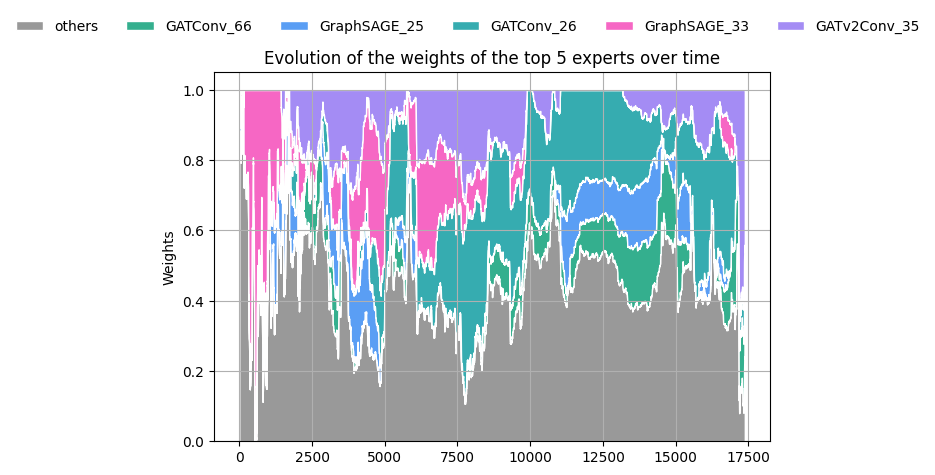

In [ ]:
# View most influential experts in the top-level mixture
max_experts = 5
W = mixture.weights 
mean_weights = np.mean(W, axis=0)
top_indices = np.argsort(mean_weights)[::-1][:max_experts]
top_experts = np.array(mixture.experts_names)[top_indices]

print(f"{max_experts} most influential experts and their average weights:")
for i, name in enumerate(top_experts, 1):
    print(f"{i}. {name} (mean weight = {mean_weights[top_indices[i-1]]:.4f})")

colors = sns.color_palette("husl", W.shape[1])
rng = np.random.default_rng(seed=0) 
rng.shuffle(colors)
mixture.plot_mixture(
    plot_type="plot_weight",
    colors=colors,
    max_experts=max_experts,
    title=f"Evolution of the weights of the top {max_experts} experts over time",
    ylabel="Weights",
)

## Bottom-up

In [ ]:
# Bottom-up aggregation
experts_bottom = pd.read_csv(f'results_{DATASET}/experts_bottom.csv', index_col=0)
target_bottom = pd.read_csv(f'results_{DATASET}/target_bottom.csv', index_col=0)
nodes_list = list(target_bottom.columns)

T = len(experts_bottom)          
step = OUT_CHANNELS                
predictions_bottom = pd.DataFrame(index=experts_bottom.index, columns=nodes_list, dtype=float)

mixtures_bottom = {}
for node in nodes_list:
    cols_node = [c for c in experts_bottom.columns if c.endswith(f"__{node}")]
    if not cols_node:
        continue

    X_node = experts_bottom[cols_node]                 # T × K_node (DataFrame)
    y_node = target_bottom[node].values.astype(float)  # (T,)
    K_node = X_node.shape[1]
    w0 = np.ones(K_node) / K_node
    pred_node = np.empty(T, dtype=float)
    pred_node[:step] = X_node.iloc[:step].values @ w0

    node_mixture = Mixture(
        y=y_node[:step],
        experts=X_node.iloc[:step],
        model="MLpol",
        loss_type="mse",
    )

    for s in range(step, T, step):
        e = min(s + step, T)
        X_blk = X_node.iloc[s:e]
        y_blk = y_node[s:e]
        pred_blk = node_mixture.predict(new_experts=X_blk)
        pred_node[s:e] = np.ravel(pred_blk)
        node_mixture.update(new_experts=X_blk, new_y=y_blk)

    predictions_bottom[node] = pred_node
    mixtures_bottom[node] = node_mixture

prediction_bottom_up = predictions_bottom.sum(axis=1).values
print(RMSE(preds=prediction_bottom_up, targets=true_top.numpy()))
print(100*MAPE(preds=prediction_bottom_up, targets=true_top.numpy()))

789.3882214954278
1.0057827529478405


Node: Auvergne_Rhone_Alpes
5 most influential experts and their average weights:
1. TAGConv_78__Auvergne_Rhone_Alpes (mean weight = 0.1911)
2. GATConv_26__Auvergne_Rhone_Alpes (mean weight = 0.0806)
3. APPNP_39__Auvergne_Rhone_Alpes (mean weight = 0.0787)
4. ChebConv_53__Auvergne_Rhone_Alpes (mean weight = 0.0696)
5. GraphSAGE_33__Auvergne_Rhone_Alpes (mean weight = 0.0693)


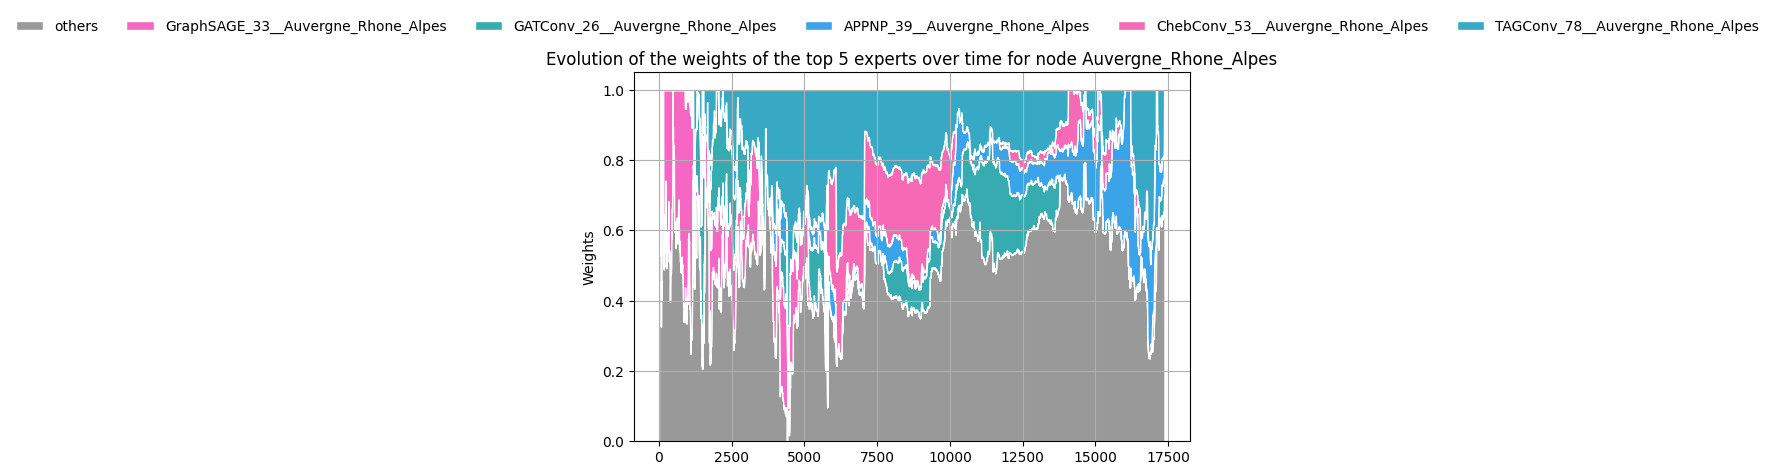

Node: Bourgogne_Franche_Comte
5 most influential experts and their average weights:
1. GATv2Conv_75__Bourgogne_Franche_Comte (mean weight = 0.1045)
2. ChebConv_69__Bourgogne_Franche_Comte (mean weight = 0.0998)
3. TAGConv_46__Bourgogne_Franche_Comte (mean weight = 0.0887)
4. GATv2Conv_67__Bourgogne_Franche_Comte (mean weight = 0.0843)
5. GCNConv_64__Bourgogne_Franche_Comte (mean weight = 0.0712)


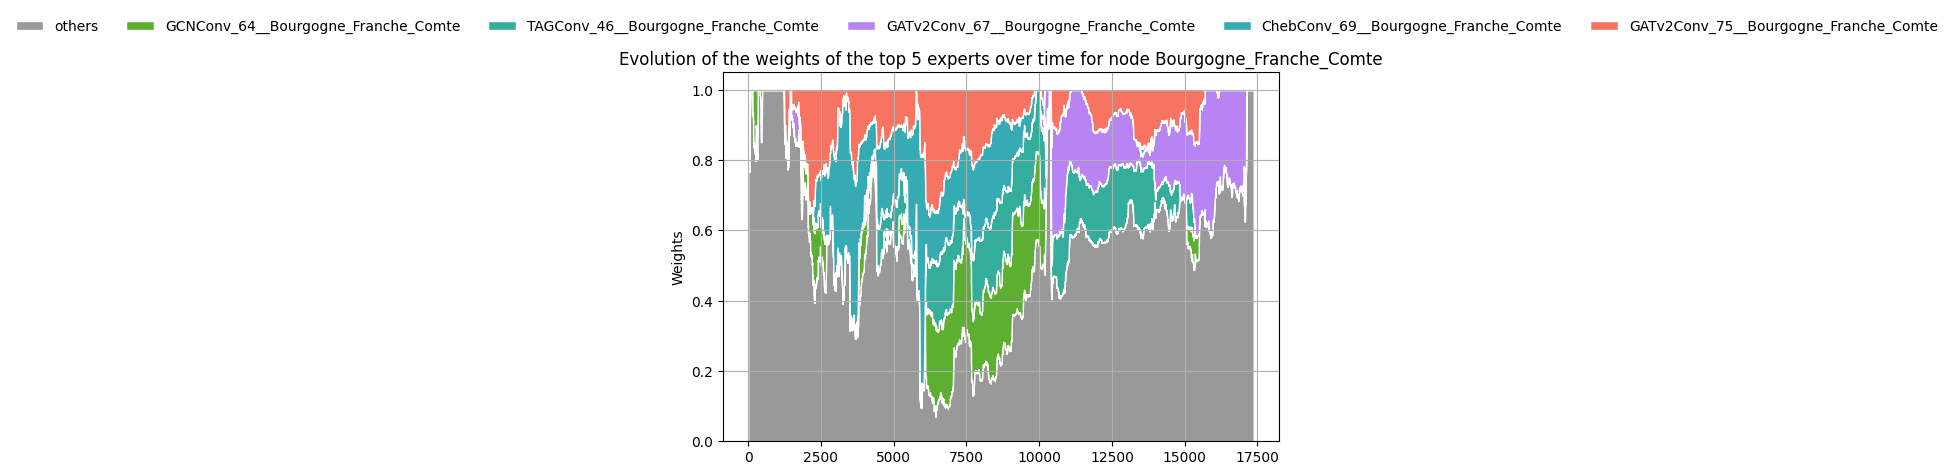

Node: Bretagne
5 most influential experts and their average weights:
1. GATv2Conv_35__Bretagne (mean weight = 0.1828)
2. ChebConv_45__Bretagne (mean weight = 0.0856)
3. GraphSAGE_17__Bretagne (mean weight = 0.0787)
4. GCNConv_64__Bretagne (mean weight = 0.0785)
5. ChebConv_69__Bretagne (mean weight = 0.0620)


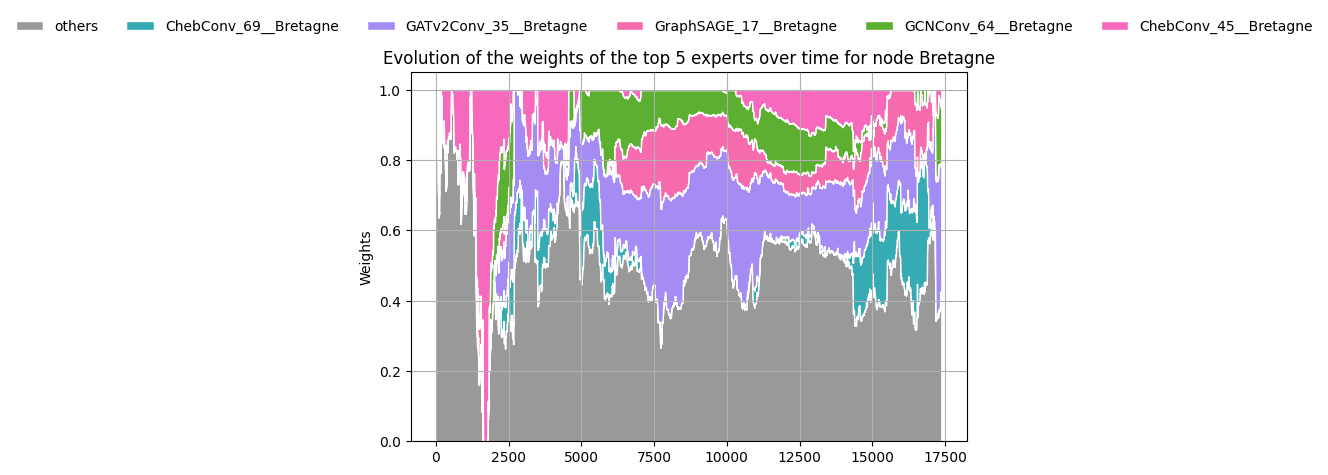

In [ ]:
# View most influential experts in the first K bottom-up mixtures
max_experts = 5
num_mixtures = 3
for node in nodes_list[:num_mixtures]:
    mixture = mixtures_bottom.get(node)
    if mixture is None:
        continue

    W = mixture.weights 
    mean_weights = np.mean(W, axis=0)
    top_indices = np.argsort(mean_weights)[::-1][:max_experts]
    top_experts = np.array(mixture.experts_names)[top_indices]

    print(f"Node: {node}")
    print(f"{max_experts} most influential experts and their average weights:")
    for i, name in enumerate(top_experts, 1):
        print(f"{i}. {name} (mean weight = {mean_weights[top_indices[i-1]]:.4f})")

    colors = sns.color_palette("husl", W.shape[1])
    rng = np.random.default_rng(seed=0) 
    rng.shuffle(colors)
    mixture.plot_mixture(
        plot_type="plot_weight",
        colors=colors,
        max_experts=max_experts,
        title=f"Evolution of the weights of the top {max_experts} experts over time for node {node}",
        ylabel="Weights",
    )

# Vizualisations

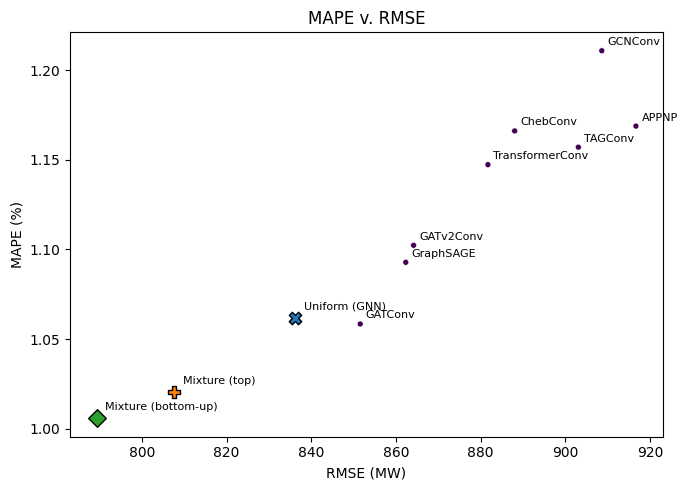

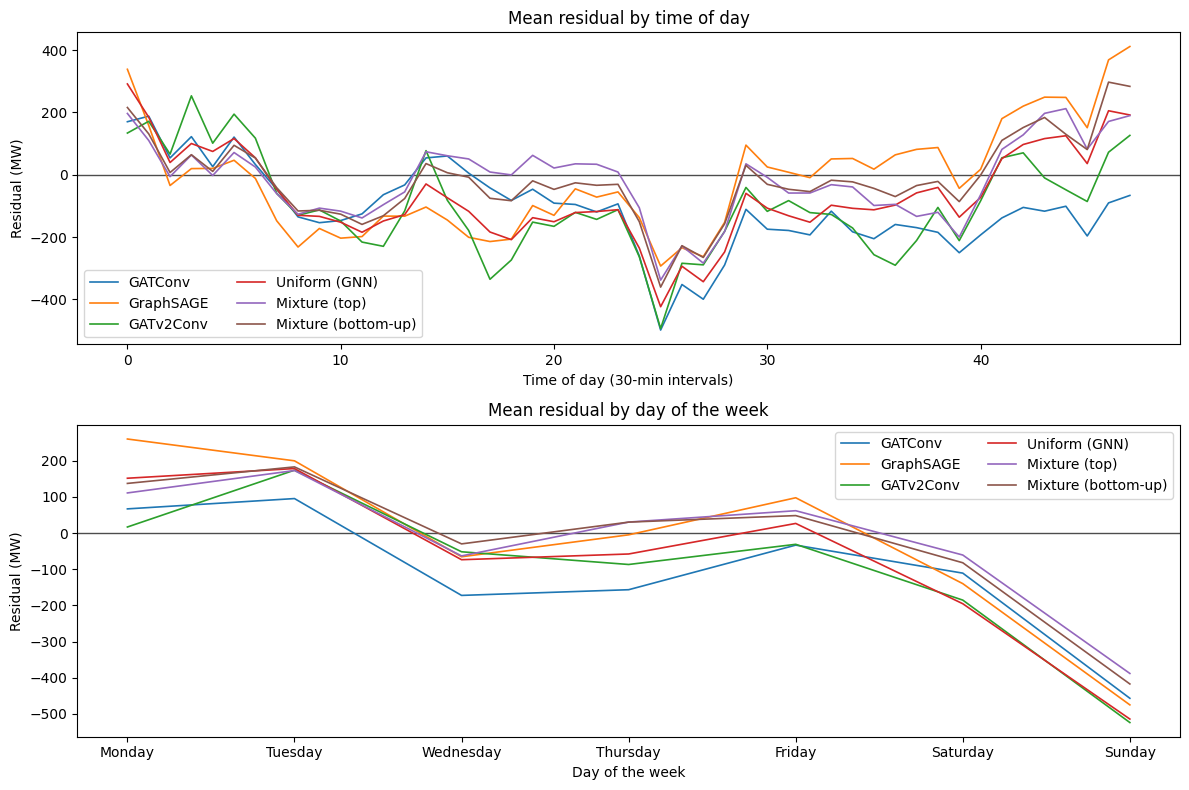

In [ ]:
# Vizualisations per-model + aggregations (uniform/mixture) + baselines
df = per_model_df.copy()
df.index.name = 'model'
df = df.reset_index()

true_np = true_top.detach().cpu().numpy()

# Uniform 
uni_np = np.asarray(avg_pred_top, dtype=float)
yt_u, yp_u = true_np[:min(len(true_np), len(uni_np))], uni_np[:min(len(true_np), len(uni_np))]
rmse_uni = RMSE(preds=yp_u, targets=yt_u).item()
mape_uni = 100 * MAPE(preds=yp_u, targets=yt_u).item()

# Mixture top-level
mix_np = np.asarray(predictions_top, dtype=float)
yt_m, yp_m = true_np[:min(len(true_np), len(mix_np))], mix_np[:min(len(true_np), len(mix_np))]
rmse_mix = RMSE(preds=yp_m, targets=yt_m).item()
mape_mix = 100 * MAPE(preds=yp_m, targets=yt_m).item()

# Mixture bottom-up
bu_np = np.asarray(prediction_bottom_up, dtype=float)
yt_bu, yp_bu = true_np[:min(len(true_np), len(bu_np))], bu_np[:min(len(true_np), len(bu_np))]
rmse_bu = RMSE(preds=yp_bu, targets=yt_bu).item()
mape_bu = 100 * MAPE(preds=yp_bu, targets=yt_bu).item()

# 1) 
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(
    data=df, x='rmse_avg_pred', y='mape_avg_pred',
    size='n_runs', hue='n_runs', palette='viridis', legend=False
)
for _, r in df.iterrows():
    ax.annotate(r['model'], (r['rmse_avg_pred'], r['mape_avg_pred']),
                textcoords='offset points', xytext=(4, 4), fontsize=8)

extras = [
    ('Uniform (GNN)', rmse_uni, mape_uni, 'X', 'tab:blue'),
    ('Mixture (top)', rmse_mix, mape_mix, 'P', 'tab:orange'),
    ('Mixture (bottom-up)', rmse_bu, mape_bu, 'D', 'tab:green'),
]
for label, x, y, marker, color in extras:
    ax.scatter(x, y, marker=marker, s=80, color=color, edgecolor='black', zorder=5)
    ax.annotate(label, (x, y), textcoords='offset points', xytext=(6, 6), fontsize=8)

ax.set_xlabel('RMSE (MW)')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE v. RMSE')
plt.tight_layout()
plt.show()

# 2) 
best = df.nsmallest(3, 'rmse_avg_pred')['model'].tolist()
Tm = min(
    len(true_np),
    *[len(per_model_avg_preds[m]) for m in best],
    len(uni_np), len(mix_np), len(bu_np),
)
yt = true_np[:Tm]

residuals = {}
for m in best:
    yp = per_model_avg_preds[m][:Tm].detach().cpu().numpy()
    residuals[m] = yp - yt
residuals['Uniform (GNN)'] = uni_np[:Tm] - yt
residuals['Mixture (top)'] = mix_np[:Tm] - yt
residuals['Mixture (bottom-up)'] = bu_np[:Tm] - yt

time_of_day_idx = np.arange(Tm) % step  # 0..47
dow_idx = pd.to_datetime(target_bottom.index[:Tm]).dayofweek.values  # 0..6

def group_means(values, group_idx, n_groups):
    return np.array([
        values[group_idx == g].mean() if np.any(group_idx == g) else np.nan
        for g in range(n_groups)
    ])

daily_means = {k: group_means(v, time_of_day_idx, step) for k, v in residuals.items()}
weekly_means = {k: group_means(v, dow_idx, 7) for k, v in residuals.items()}
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].axhline(0.0, color='black', linewidth=1.0, alpha=0.7)
x_day = np.arange(step)
for label, arr in daily_means.items():
    axes[0].plot(x_day, arr, label=label, linewidth=1.2)
axes[0].set_title('Mean residual by time of day')
axes[0].set_xlabel('Time of day (30-min intervals)')
axes[0].set_ylabel('Residual (MW)')
axes[0].legend(ncol=2)

axes[1].axhline(0.0, color='black', linewidth=1.0, alpha=0.7)
x_week = np.arange(7)
for label, arr in weekly_means.items():
    axes[1].plot(x_week, arr, label=label, linewidth=1.2)
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1].set_xticks(x_week)
axes[1].set_xticklabels(day_names)
axes[1].set_title('Mean residual by day of the week')
axes[1].set_xlabel('Day of the week')
axes[1].set_ylabel('Residual (MW)')
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()